## 00_PromptExperiment: Items & Attributes Task Results Analysis

In [1413]:
import pandas as pd
import csv
import requests
import json
import time
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import string
from tabulate import tabulate
import re

### Part 1: 6 Prompts Comparison

### Raw Outputs

In [1414]:
# Import all data and stack

items_files = ["00_promptsexp_itemstask_openmodels_raw.csv","00_promptsexp_itemstask_gemini_raw.csv","00_promptsexp_itemstask_deepseek_raw.csv"]
attributes_file = ["00_promptsexp_attributestask_openmodels_raw.csv","00_promptsexp_attributestask_gemini_raw.csv","00_promptsexp_attributestask_deepseek_raw.csv"]

items_df = pd.DataFrame()
attributes_df = pd.DataFrame()

for i in range(len(items_files)):
    tmp_items_df = pd.read_csv(items_files[i], dtype=str, encoding = "utf-8")
    items_df = pd.concat([items_df, tmp_items_df], ignore_index=True)
    tmp_attributes_df = pd.read_csv(attributes_file[i], dtype=str, encoding = "utf-8")
    attributes_df = pd.concat([attributes_df, tmp_attributes_df], ignore_index=True)

In [1415]:
items_df.head()

,model,prompt,prompt_id,runtime,output
0,Qwen/Qwen2.5-7B-Instruct,\nThe procedure will be as follows: First you ...,0,2.49430418,Certainly! Here are some items that typically ...
1,Qwen/Qwen2.5-7B-Instruct,\nThe procedure will be as follows: First you ...,0,2.488170385,Certainly! Here are some items commonly includ...
2,Qwen/Qwen2.5-7B-Instruct,\nThe procedure will be as follows: First you ...,0,2.485515118,Certainly! Here are some items that fall under...
3,Qwen/Qwen2.5-7B-Instruct,\nThe procedure will be as follows: First you ...,0,2.487828255,Certainly! Here are some items that typically ...
4,Qwen/Qwen2.5-7B-Instruct,\nThe procedure will be as follows: First you ...,0,2.490246773,Certainly! Here are some items that typically ...


In [1416]:
attributes_df.head()

,model,prompt,prompt_id,runtime,output
0,Qwen/Qwen2.5-7B-Instruct,\r\nWrite all of the attributes of the object ...,0,1.8797800540924072,Certainly! Here is a list of attributes and ch...
1,Qwen/Qwen2.5-7B-Instruct,\r\nWrite all of the attributes of the object ...,0,1.4951231479644775,Certainly! Here are some attributes and charac...
2,Qwen/Qwen2.5-7B-Instruct,\r\nWrite all of the attributes of the object ...,0,1.4941344261169434,Certainly! Here is a list of attributes and ch...
3,Qwen/Qwen2.5-7B-Instruct,\r\nWrite all of the attributes of the object ...,0,1.5002601146697998,Certainly! Here are several attributes and cha...
4,Qwen/Qwen2.5-7B-Instruct,\r\nWrite all of the attributes of the object ...,0,1.4976129531860352,Certainly! Here are various attributes and cha...


In [ ]:
# Counting NA outputs

# Items
na_count = items_df['output'].isna().sum()
print(f"\nNumber of NA items outputs: {na_count}")

na_values = items_df[items_df['output'].isna()]
models_na_counts = na_values['model'].value_counts()
print("NA items for each model:")
print(models_na_counts)


# Attributes
na_count = attributes_df['output'].isna().sum()
print(f"\nNumber of NA attributes outputs: {na_count}")

na_values = attributes_df[attributes_df['output'].isna()]
models_na_counts = na_values['model'].value_counts()
print("NA attributes for each model:")
print(models_na_counts)


Number of NA items outputs: 0
NA items for each model:
Series([], Name: count, dtype: int64)

Number of NA attributes outputs: 0
NA attributes for each model:
Series([], Name: count, dtype: int64)


In [ ]:
# Models

items_df['model'] = items_df['model'].where(~items_df['model'].str.contains('/'), items_df['model'].str.split('/').str[1])
attributes_df['model'] = attributes_df['model'].where(~attributes_df['model'].str.contains('/'), attributes_df['model'].str.split('/').str[1])

items_df = items_df[items_df['model'] != 'model']
attributes_df = attributes_df[attributes_df['model'] != 'model']

models = items_df['model'].unique()
print("Items Task: Tested Models: \n", items_df['model'].unique(), "\n")

models = attributes_df['model'].unique()
print("Attributes Task: Tested Models: \n", items_df['model'].unique(), "\n")

Items Task: Tested Models: 
 ['Qwen2.5-7B-Instruct' 'Qwen2.5-14B-Instruct' 'Qwen2.5-32B-Instruct'
 'Qwen2.5-72B-Instruct' 'Meta-Llama-3.1-8B-Instruct'
 'Meta-Llama-3.1-70B-Instruct' 'gemini-3-pro' 'deepseek-r1-0528'] 

Attributes Task: Tested Models: 
 ['Qwen2.5-7B-Instruct' 'Qwen2.5-14B-Instruct' 'Qwen2.5-32B-Instruct'
 'Qwen2.5-72B-Instruct' 'Meta-Llama-3.1-8B-Instruct'
 'Meta-Llama-3.1-70B-Instruct' 'gemini-3-pro' 'deepseek-r1-0528'] 



In [ ]:
# Check for NAs
print("Len items_df (before filtering):", len(items_df))
print("Len items_df (after filtering):", len(items_df.dropna()))

print("Len attributes_df (before filtering):", len(attributes_df))
print("Len items_df (after filtering):", len(attributes_df.dropna()))

Len items_df (before filtering): 280
Len items_df (after filtering): 280
Len attributes_df (before filtering): 280
Len items_df (after filtering): 280


In [1420]:
# Entries check

print("\nItems Task:")
items_df_counts = items_df['model'].value_counts()
print(items_df_counts)

print("\nAttributes Task:")
attributes_df_counts = attributes_df['model'].value_counts()
print(attributes_df_counts)



Items Task:
model
Qwen2.5-7B-Instruct            35
Qwen2.5-14B-Instruct           35
Qwen2.5-32B-Instruct           35
Qwen2.5-72B-Instruct           35
Meta-Llama-3.1-8B-Instruct     35
Meta-Llama-3.1-70B-Instruct    35
gemini-3-pro                   35
deepseek-r1-0528               35
Name: count, dtype: int64

Attributes Task:
model
Qwen2.5-7B-Instruct            35
Qwen2.5-14B-Instruct           35
Qwen2.5-32B-Instruct           35
Qwen2.5-72B-Instruct           35
Meta-Llama-3.1-8B-Instruct     35
Meta-Llama-3.1-70B-Instruct    35
gemini-3-pro                   35
deepseek-r1-0528               35
Name: count, dtype: int64


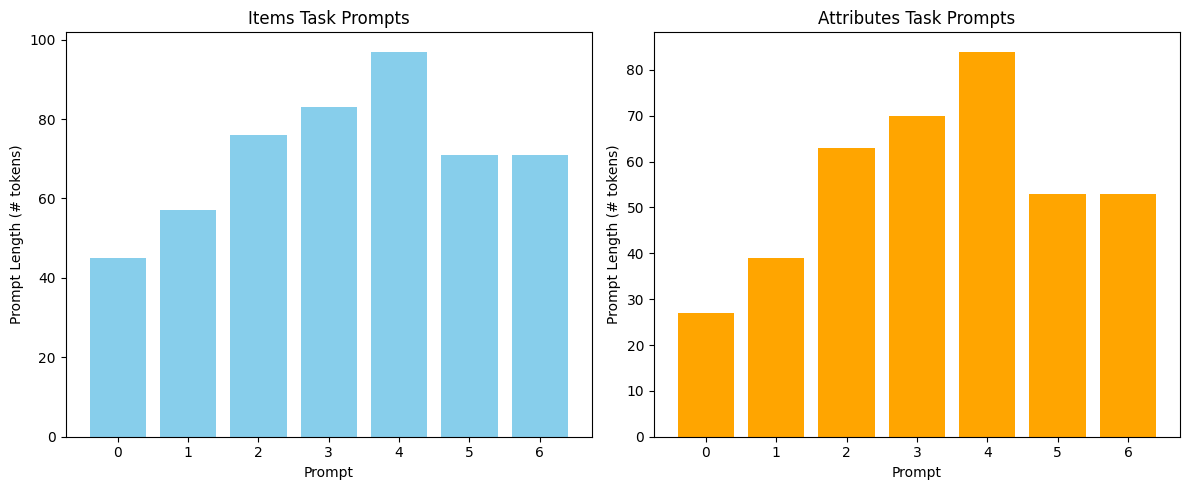

In [ ]:
# Input length

# Function to count tokens
def count_tokens(string):
    tokens = string.split()  
    return len(tokens)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

items_prompts = items_df['prompt'].unique()
attributes_prompts = attributes_df['prompt'].unique()

# Counting prompts length
items_prompts_len = []
attributes_prompts_len = []
for i in range(len(items_prompts)):
    items_prompts_len.append(count_tokens(items_prompts[i]))
    attributes_prompts_len.append(count_tokens(attributes_prompts[i]))

# Items Plot
axs[0].bar(items_df['prompt_id'].unique(), items_prompts_len, color='skyblue')
axs[0].set_title("Items Task Prompts")
axs[0].set_xlabel("Prompt")
axs[0].set_ylabel("Prompt Length (# tokens)")

# Attributes Plot
axs[1].bar(attributes_df['prompt_id'].unique(), attributes_prompts_len, color='orange')
axs[1].set_title("Attributes Task Prompts")
axs[1].set_xlabel("Prompt")
axs[1].set_ylabel("Prompt Length (# tokens)")

plt.tight_layout()
plt.show()

In [1422]:
items_prompts = items_df['prompt'].unique()
items_prompts

array(['\nThe procedure will be as follows: First you will be given the name or description of a category. Then you will write as many items included in that category as you can, in whatever order they happen to occur to you. The category is: "furniture".\n',
       '\nThe procedure will be as follows: First you will be given the name or description of a category. Then you will write as many items included in that category as you can, in whatever order they happen to occur to you. The category is: "furniture".\nProvide your answer in plain text as a comma-separated list of items.\n',
       '\nThe purpose of this experiment is to find out what items or objects belong to various categories or classes.\nThe procedure will be as follows: First you will be given the name or description of a category. Then you will write as many items included in that category as you can, in whatever order they happen to occur to you. The category is: "furniture".\nProvide your answer in plain text as a com

In [1423]:
attributes_prompts = items_df['prompt'].unique()
attributes_prompts

array(['\nThe procedure will be as follows: First you will be given the name or description of a category. Then you will write as many items included in that category as you can, in whatever order they happen to occur to you. The category is: "furniture".\n',
       '\nThe procedure will be as follows: First you will be given the name or description of a category. Then you will write as many items included in that category as you can, in whatever order they happen to occur to you. The category is: "furniture".\nProvide your answer in plain text as a comma-separated list of items.\n',
       '\nThe purpose of this experiment is to find out what items or objects belong to various categories or classes.\nThe procedure will be as follows: First you will be given the name or description of a category. Then you will write as many items included in that category as you can, in whatever order they happen to occur to you. The category is: "furniture".\nProvide your answer in plain text as a com

In [ ]:
# RUNTIMES ITEMS TASK

items_df['runtime'] = pd.to_numeric(items_df['runtime'])
average_runtime = items_df.groupby(['model', 'prompt_id'])['runtime'].mean().reset_index()
pivot_df = average_runtime.pivot(index='prompt_id', columns='model', values='runtime').reset_index()
order = average_runtime.groupby('model')['runtime'].mean().sort_values().index.tolist()
pivot_df = pivot_df[['prompt_id'] + order]
mean_runtimes = average_runtime.groupby('prompt_id')['runtime'].mean()

# Plotting
textures = ['/', '-']  

ax = pivot_df.plot(x='prompt_id', kind='bar', figsize=(10, 6), edgecolor='black')

num_models = len(order)  

for i, model in enumerate(order):
    for j in range(len(pivot_df)):
        bar_index = j * num_models + i
        if bar_index > 41 and bar_index <49:
            ax.patches[bar_index].set_hatch(textures[0])
        elif bar_index > 48:
            ax.patches[bar_index].set_hatch(textures[1])
plt.xlabel('Prompt')
plt.ylabel('Average Runtime per output (seconds)')
plt.xticks(rotation=0)
plt.title("Items Task")

# legend
mean_marker = plt.scatter([], [], color='black', s=80, marker='x', label='Mean Runtime')  
for i, mean_value in enumerate(mean_runtimes):
    plt.scatter(i, mean_value, color='black', s=80, marker='x')
ax.legend(title='Models', loc='upper right')

plt.tight_layout()
plt.show()

# different textures indicating that the answers were obtained in different ways (e.g., call to huggingface, api google cloud call, api openrouter)

In [ ]:
# RUNTIMES ATTRIBUTES TASK

attributes_df['runtime'] = pd.to_numeric(attributes_df['runtime'])
average_runtime = attributes_df.groupby(['model', 'prompt_id'])['runtime'].mean().reset_index()
pivot_df = average_runtime.pivot(index='prompt_id', columns='model', values='runtime').reset_index()
order = average_runtime.groupby('model')['runtime'].mean().sort_values().index.tolist()
pivot_df = pivot_df[['prompt_id'] + order]
mean_runtimes = average_runtime.groupby('prompt_id')['runtime'].mean()

# Plotting
textures = ['/', '-']  

ax = pivot_df.plot(x='prompt_id', kind='bar', figsize=(10, 6), edgecolor='black')

num_models = len(order)  

for i, model in enumerate(order):
    for j in range(len(pivot_df)):
        bar_index = j * num_models + i
        if bar_index > 41 and bar_index <49:
            ax.patches[bar_index].set_hatch(textures[0])
        elif bar_index > 48:
            ax.patches[bar_index].set_hatch(textures[1])
plt.xlabel('Prompt')
plt.ylabel('Average Runtime per output (seconds)')
plt.xticks(rotation=0)
plt.title("Attributes Task")

# legend
mean_marker = plt.scatter([], [], color='black', s=80, marker='x', label='Mean Runtime')  
for i, mean_value in enumerate(mean_runtimes):
    plt.scatter(i, mean_value, color='black', s=80, marker='x')
ax.legend(title='Models', loc='upper right')

plt.tight_layout()
plt.show()

# different textures indicating that the answers were obtained in different ways (e.g., call to huggingface, api google cloud call, api openrouter)

In [1426]:
# Show example prompts for each models (pre-processing) for meta-lama 7B - Items Task

print("Items Task Outputs Before Processing:\n")
num_prompts = 7
for i in range(num_prompts):
    output = items_df.loc[(items_df['prompt_id'] == f"{i}") & (items_df['model'] == "Meta-Llama-3.1-8B-Instruct"), 'output'].iloc[0]
    print(f"Prompt {i} output:", output, "\n")

Items Task Outputs Before Processing:

Prompt 0 output: Here's a list of furniture items that come to mind:

1. Chairs
2. Tables
3. Sofas
4. Beds
5. Desks
6. Dressers
7. Nightstands
8 

Prompt 1 output: bed, dresser, nightstand, desk, chair, sofa, table, bookshelf, bookcase, coffee table, dining table, TV stand, cabinet, wardrobe, closet, ottoman, armchair, recliner, loveseat, end table, night lamp, lamp, rug 

Prompt 2 output: bed, chair, table, desk, sofa, bookshelf, dresser, nightstand, cabinet, shelf, bench, ottoman, armchair, coffee table, bookcase, wardrobe, TV stand, recliner, loveseat, TV cabinet, dresser mirror, storage unit, dining table, dining chair, side table, TV console, TV media center, stool, file cabinet 

Prompt 3 output: chair, table, bed, desk, sofa, bookshelf, dresser, nightstand, armchair, cabinet, wardrobe, coffee table, dining table, bookcase, ottoman, recliner, TV stand, shelves, mirror, dresser, dresser, lamp, piano 

Prompt 4 output: chair, table, bed, sofa,

In [1427]:
# Show example prompts for each models (pre-processing) for meta-lama 7B - Attributes Task

print("Atttributes Task Outputs Before Processing:\n")
num_prompts = 7
for i in range(num_prompts):
    output = attributes_df.loc[(attributes_df['prompt_id'] == f"{i}") & (attributes_df['model'] == "Meta-Llama-3.1-8B-Instruct"), 'output'].iloc[0]
    print(f"Prompt {i} output:", output, "\n")

Atttributes Task Outputs Before Processing:

Prompt 0 output: Here's a comprehensive list of attributes or characteristics that I can think of for the object "desk":

**Physical Attributes:**

1. 

Prompt 1 output: Here's a list of attributes or characteristics of the object "desk":

height, width, length, material (wood, metal, glass, etc.), color, shape (rectangular, L-shaped 

Prompt 2 output: Here's a list of attributes and characteristics of the object "desk":

sturdy, flat, horizontal, rectangular, stationary, stationary furniture, made of various materials (wood, metal, glass, etc.), has legs or a base, supports weight, has a surface, has a top, has drawers or compartments, 

Prompt 3 output: Here's a list of attributes and characteristics of the object "desk":

stationary, furniture, rectangular, flat, surface, horizontal, solid, wooden, metal, plastic, often found in offices, used for working, used for studying, used for writing, has drawers or shelves, has a top, has legs or 

In [ ]:
# Counting output length per model per prompt

model_mean_token_counts = {model: {} for model in models}

for model in models:
  
    for prompt_type in items_df['prompt_id'].unique():
        sub_df_items = items_df[(items_df['model'] == model) & (items_df['prompt_id'] == prompt_type)]
        sub_df_attributes = attributes_df[(attributes_df['model'] == model) & (attributes_df['prompt_id'] == prompt_type)]

        
        if not sub_df_items.empty:
            token_counts_items = sub_df_items['output'].apply(lambda x: len(x.split()))
            model_mean_token_counts[model][f'items_{prompt_type}'] = np.mean(token_counts_items)

        
        if not sub_df_attributes.empty:
            token_counts_attributes = sub_df_attributes['output'].apply(lambda x: len(x.split()))
            model_mean_token_counts[model][f'attributes_{prompt_type}'] = np.mean(token_counts_attributes)


mean_token_counts_items = [model_mean_token_counts[model].get(f'items_{prompt_id}', 0) for model in models for prompt_id in items_df['prompt_id'].unique()]
mean_token_counts_attributes = [model_mean_token_counts[model].get(f'attributes_{prompt_id}', 0) for model in models for prompt_id in attributes_df['prompt_id'].unique()]

num_prompt_types = len(items_df['prompt_id'].unique())

# Plot
fig, axs = plt.subplots(2, 1, figsize=(14, 8))

x_items = np.arange(num_prompt_types)
x_attributes = np.arange(num_prompt_types)
width = 0.1  

# Items subplot
for idx, model in enumerate(models):
    axs[0].bar(x_items + idx * width, mean_token_counts_items[idx * num_prompt_types: (idx + 1) * num_prompt_types], width, label=model, align='center')

axs[0].set_xlabel('Prompt Type')
axs[0].set_ylabel('Mean # Tokens')
axs[0].set_title('Items Task')
axs[0].set_xticks(x_items + width * (len(models) - 1) / 2)
axs[0].set_xticklabels(items_df['prompt_id'].unique())
axs[0].legend(title='Models', bbox_to_anchor=(-0.06, 0.85))

# Attributes subplot
for idx, model in enumerate(models):
    axs[1].bar(x_attributes + idx * width, mean_token_counts_attributes[idx * num_prompt_types: (idx + 1) * num_prompt_types], width, label=model, align='center')

axs[1].set_xlabel('Prompt Type')
axs[1].set_ylabel('Mean # Tokens')
axs[1].set_title('Attributes Task')
axs[1].set_xticks(x_attributes + width * (len(models) - 1) / 2)
axs[1].set_xticklabels(attributes_df['prompt_id'].unique())
axs[1].legend(title='Models', bbox_to_anchor=(-0.06, 0.85))

plt.tight_layout()
plt.show()


In [ ]:
# Plot difference in output per prompt type before&after processing

items_files = ['00_promptsexp_itemstask_openmodels_processed.csv','00_promptsexp_itemstask_gemini_processed.csv','00_promptsexp_itemstask_deepseek_processed.csv']
new_data_df = pd.DataFrame()
for i in range(len(items_files)):
    tmp_items_df = pd.read_csv(items_files[i], dtype=str, encoding = "utf-8")
    new_data_df = pd.concat([items_df, tmp_items_df], ignore_index=True)

# Assuming `models` and `num_prompt_types` are defined elsewhere in your code
mean_token_counts_new = {}
for model in models:
    mean_token_counts_new[model] = {}
    for prompt_id in new_data_df['prompt_id'].unique():
        sub_df_new = new_data_df[(new_data_df['model'] == model) & (new_data_df['prompt_id'] == prompt_id)]
        if not sub_df_new.empty:
            token_counts_new = sub_df_new['output'].apply(lambda x: len(x.split()))
            mean_token_counts_new[model][f'new_{prompt_id}'] = np.mean(token_counts_new)

# Prepare mean token counts for both datasets for plotting
mean_token_counts_items_values = [model_mean_token_counts[model].get(f'items_{prompt_id}', 0) for model in models for prompt_id in items_df['prompt_id'].unique()]
mean_token_counts_new_values = [mean_token_counts_new[model].get(f'new_{prompt_id}', 0) for model in models for prompt_id in new_data_df['prompt_id'].unique()]

# Plot setup
fig, ax = plt.subplots(figsize=(14, 8)) 

x = np.arange(num_prompt_types) 
width = 0.1  

colors = plt.cm.tab10(np.arange(len(models)))

for idx, model in enumerate(models):
    ax.bar(x + idx * width, mean_token_counts_items_values[idx * num_prompt_types: (idx + 1) * num_prompt_types], 
           width, color=colors[idx], alpha=0.5, align='center')

for idx, model in enumerate(models):
    ax.bar(x + idx * width, mean_token_counts_new_values[idx * num_prompt_types: (idx + 1) * num_prompt_types],
           width, edgecolor='black',color=colors[idx], align='center', alpha=1)

ax.set_xlabel('Prompt Type')
ax.set_ylabel('Mean # Tokens')
ax.set_title('Items Task')
ax.set_xticks(x + width * (len(models) - 1) / 2)
ax.set_xticklabels(items_df['prompt_id'].unique())
legend_elements = [Patch(facecolor='grey', edgecolor='white', alpha=0.5, label='Pre-processing'), Patch(facecolor='grey', edgecolor='white', alpha=1, label='Post-processing')] 
ax.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.show()


In [ ]:
# Plot difference in output per prompt type before&after processing

attributes_files = ['00_promptsexp_attributestask_openmodels_processed.csv','00_promptsexp_attributestask_gemini_processed.csv','00_promptsexp_attributestask_deepseek_processed.csv']
new_data_df = pd.DataFrame()
for i in range(len(attributes_files)):
    tmp_items_df = pd.read_csv(attributes_files[i], dtype=str, encoding = "utf-8")
    new_data_df = pd.concat([attributes_df, tmp_attributes_df], ignore_index=True)

mean_token_counts_new = {}
for model in models:
    mean_token_counts_new[model] = {}
    for prompt_id in new_data_df['prompt_id'].unique():
        sub_df_new = new_data_df[(new_data_df['model'] == model) & (new_data_df['prompt_id'] == prompt_id)]
        if not sub_df_new.empty:
            token_counts_new = sub_df_new['output'].apply(lambda x: len(x.split()))
            mean_token_counts_new[model][f'new_{prompt_id}'] = np.mean(token_counts_new)

mean_token_counts_items_values = [model_mean_token_counts[model].get(f'items_{prompt_id}', 0) for model in models for prompt_id in attributes_df['prompt_id'].unique()]
mean_token_counts_new_values = [mean_token_counts_new[model].get(f'new_{prompt_id}', 0) for model in models for prompt_id in new_data_df['prompt_id'].unique()]

fig, ax = plt.subplots(figsize=(14, 8)) 

x = np.arange(num_prompt_types) 
width = 0.1  

colors = plt.cm.tab10(np.arange(len(models)))

for idx, model in enumerate(models):
    ax.bar(x + idx * width, mean_token_counts_items_values[idx * num_prompt_types: (idx + 1) * num_prompt_types], 
           width, color=colors[idx], alpha=0.5, align='center')

for idx, model in enumerate(models):
    ax.bar(x + idx * width, mean_token_counts_new_values[idx * num_prompt_types: (idx + 1) * num_prompt_types],
           width, edgecolor='black',color=colors[idx], align='center', alpha=1)

ax.set_xlabel('Prompt Type')
ax.set_ylabel('Mean # Tokens')
ax.set_title('Attributes Task')
ax.set_xticks(x + width * (len(models) - 1) / 2)
ax.set_xticklabels(items_df['prompt_id'].unique())
legend_elements = [Patch(facecolor='grey', edgecolor='white', alpha=0.5, label='Pre-processing'), Patch(facecolor='grey', edgecolor='white', alpha=1, label='Post-processing')] 
ax.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.show()

### Part 2: Prompt 6 Analyses Only

In [1433]:
# Adding additional outputs from extra 5 repetitions of prompt_6

items_files = ["00_promptsexp_itemstask_allmodels_prompt6_raw.csv"]
attributes_file = ["00_promptsexp_attributestask_allmodels_prompt6_raw.csv"]

for i in range(len(items_files)):
    items_df = pd.read_csv(items_files[i], dtype=str, encoding = "utf-8")
    attributes_df = pd.read_csv(attributes_file[i], dtype=str, encoding = "utf-8")

In [1434]:
# Models

items_df['model'] = items_df['model'].where(~items_df['model'].str.contains('/'), items_df['model'].str.split('/').str[1])
attributes_df['model'] = attributes_df['model'].where(~attributes_df['model'].str.contains('/'), attributes_df['model'].str.split('/').str[1])

models = items_df['model'].unique()
print("Tested Models: \n", items_df['model'].unique(), "\n")

Tested Models: 
 ['Qwen2.5-7B-Instruct' 'Qwen2.5-14B-Instruct' 'Qwen2.5-32B-Instruct'
 'Qwen2.5-72B-Instruct' 'Meta-Llama-3.1-8B-Instruct'
 'Meta-Llama-3.1-70B-Instruct' 'gemini-3-pro' 'deepseek-r1-0528'] 



In [ ]:
# Filling any missing values

# Items
na_count = items_df['output'].isna().sum()
print(f"\nNumber of NA items outputs: {na_count}")
# Checking for which models output is NA
na_values = items_df[items_df['output'].isna()]
models_na_counts = na_values['model'].value_counts()
print("NA items for each model:")
print(models_na_counts)

# Attributes
na_count = attributes_df['output'].isna().sum()
print(f"\nNumber of NA attributes outputs: {na_count}")
na_values = attributes_df[attributes_df['output'].isna()]
models_na_counts = na_values['model'].value_counts()
print("NA attributes for each model:")
print(models_na_counts)



Number of NA items outputs: 0
NA items for each model:
Series([], Name: count, dtype: int64)

Number of NA attributes outputs: 2
NA attributes for each model:
model
deepseek-r1-0528    2
Name: count, dtype: int64


In [ ]:
# Plotting output lengths (# tokens, not items) per model

reps_items = 30 
reps_attributes = 30

model_token_counts_items = {model: [] for model in models}
model_token_counts_attributes = {model: [] for model in models}

# Step 1: Collect token counts for each model
for model in models:
    
    sub_df_items = items_df[(items_df['model'] == model) & (items_df['prompt_id'] == "6")]
    sub_df_attributes = attributes_df[(attributes_df['model'] == model) & (attributes_df['prompt_id'] == "6")]

    for index, row in sub_df_items.iterrows():
        output = row['output']
        token_count = len(output.split()) if isinstance(output, str) else 0 # to deal with NaN
        model_token_counts_items[model].append(token_count)
    token_counts_items = [model_token_counts_items[model] for model in models]
    
    for index, row in sub_df_attributes.iterrows():
        output = row['output']
        token_count = len(output.split()) if isinstance(output, str) else 0 # to deal with NaN
        model_token_counts_attributes[model].append(token_count)
    token_counts_attributes = [model_token_counts_attributes[model] for model in models]

num_models = len(models)

# Plot
fig, axs = plt.subplots(2,1,figsize=(14, 8))

x_items = np.arange(reps_items)  
x_attributes = np.arange(reps_attributes) 
width = 0.1  

# items subplot
for idx, model in enumerate(models):
    axs[0].bar(x_items + idx * width, token_counts_items[idx], width, label=model, align='center')
axs[0].set_xlabel('Prompt Repetition')
axs[0].set_ylabel('# Tokens')
axs[0].set_title('Items Task')
axs[0].set_xticks(x_items + width * (num_models - 1) / 2)
axs[0].set_xticklabels(range(1, reps_items + 1))
axs[0].legend(title='Models', bbox_to_anchor=(-0.06, 0.85))

# attributes subplot
for idx, model in enumerate(models):
    axs[1].bar(x_attributes + idx * width, token_counts_attributes[idx], width, label=model, align='center')
axs[1].set_xlabel('Prompt Repetition')
axs[1].set_ylabel('# Tokens')
axs[1].set_title('Attributes Task')
axs[1].set_xticks(x_attributes + width * (num_models - 1) / 2) 
axs[1].set_xticklabels(range(1, reps_attributes + 1))
axs[1].legend(title='Models', bbox_to_anchor=(-0.06, 0.85))

plt.tight_layout()
plt.show()

#### Preprocessing Prompt 6 Outputs

##### Step 1 : Semi-Automatic Processing

In [1437]:
# Items Outputs & AUTO-PREPROCESSING
prompt6_items = items_df.loc[items_df['prompt_id'] == "6"].copy()

# Eliminate concatenation rows
prompt6_items = prompt6_items[prompt6_items.iloc[:, 0] != 'model']

# Automatic processing function
def modify_items(value):
    if isinstance(value, str):
        # Replace underscores with spaces
        value = value.replace("_", " ")
        
        # Remove whitespaces around commas
        value = re.sub(r'\s*,\s*', ',', value)  # Remove spaces around commas

        elements = [elem.strip() for elem in value.split(',')]
        
        # Modify each element, removing 's' if it is present at the end
        modified_elements = []
        for elem in elements:
            if elem.endswith('s'): # Remove trailing 's'
                modified_elements.append(elem[:-1].strip())
            else:
                modified_elements.append(elem.strip())
        
        return ','.join(modified_elements).strip()
    
    return value

# Processing the 'output' column
prompt6_items['output'] = prompt6_items['output'].str.lower()
prompt6_items['output'] = prompt6_items['output'].str.rstrip(string.punctuation).str.strip()  
prompt6_items['output'] = prompt6_items['output'].apply(modify_items)

# Display the processed output
print(prompt6_items['output'])


0      sofa,bed,table,chair,desk,dresser,couch,wardro...
1      sofa,bed,table,chair,desk,couch,dining table,w...
2      sofa,chair,table,bed,dresser,wardrobe,desk,nig...
3      sofa,chair,table,bed,desk,dresser,cabinet,shel...
4      sofa,chair,table,bed,desk,dresser,couch,wardro...
                             ...                        
235    chair,sofa,table,bed,desk,stool,bench,cabinet,...
236    sofa,chair,table,bed,desk,dresser,cabinet,book...
237    chair,sofa,bed,table,desk,dresser,wardrobe,boo...
238    chair,sofa,couch,table,bench,bed,desk,wardrobe...
239    chair,table,sofa,bed,desk,dresser,bookshelf,ca...
Name: output, Length: 240, dtype: object


In [1438]:
# save to new file 
#prompt6_items.to_csv('00_promptsexp_itemstask_allmodels_prompt6_processed.csv',index=False, quoting=csv.QUOTE_ALL, encoding='utf-8')

In [1439]:
# Attributes Outputs & AUTO-PREPROCESSING
prompt6_attributes = attributes_df.loc[attributes_df['prompt_id'] == "6"].copy()
prompt6_attributes['output'] = prompt6_attributes['output'].str.lower()
prompt6_attributes['output'] = prompt6_attributes['output'].str.rstrip(string.punctuation).str.strip()  
prompt6_attributes['output'] = prompt6_attributes['output'].str.strip()

# Eliminate concatenation rows
prompt6_attributes = prompt6_attributes[prompt6_attributes.iloc[:, 0] != 'model']

# Automatic processing function
def modify_items(value):
    if isinstance(value, str):
        # Replace underscores with spaces
        value = value.replace("_", " ")
        
        # Remove whitespaces around commas
        value = re.sub(r'\s*,\s*', ',', value)  # Remove spaces around commas

        elements = [elem.strip() for elem in value.split(',')]
        
        # Modify each element, removing 's' if it is present at the end
        modified_elements = []
        for elem in elements:
            if elem.endswith('s'): # Remove trailing 's'
                modified_elements.append(elem[:-1].strip())
            else:
                modified_elements.append(elem.strip())
        
        return ','.join(modified_elements).strip()
    
    return value

# Processing the 'output' column
prompt6_attributes['output'] = prompt6_attributes['output'].str.lower()
prompt6_attributes['output'] = prompt6_attributes['output'].str.rstrip(string.punctuation).str.strip()  
prompt6_attributes['output'] = prompt6_attributes['output'].apply(modify_items)

# Display the processed output
print(prompt6_attributes['output'])

0      wooden,metallic,glas,plastic,hard,solid,flat,h...
1      wooden,metallic,flat,hard,smooth,rectangular,h...
2      wooden,metal,glas,plastic,composite,rectangula...
3      wooden,metal,glas,plastic,laminate,flat,hard,s...
4      wooden,metal,glas,plastic,flat,rectangular,l-s...
                             ...                        
239    flat,rectangular,wooden,sturdy,heavy,stationar...
240    flat,rectangular,sturdy,stationary,wooden,meta...
241    rectangular,flat,sturdy,wooden,four-legged,sta...
242    flat,sturdy,rectangular,wooden,large,heavy,sta...
243    flat,rectangular,sturdy,wooden,large,heavy,sta...
Name: output, Length: 240, dtype: object


In [1440]:
# save to new file 
#prompt6_attributes.to_csv('00_promptsexp_attributestask_allmodels_prompt6_processed.csv',index=False, quoting=csv.QUOTE_ALL, encoding='utf-8')

##### Step 2: Post - Manual Processing

In [1441]:
# Re-importing after manual processing

items_df = pd.read_csv('00_promptsexp_itemstask_allmodels_prompt6_processed.csv', dtype=str, quoting=csv.QUOTE_ALL, encoding = "utf-8")
attributes_df = pd.read_csv('00_promptsexp_attributestask_allmodels_prompt6_processed.csv', dtype=str, quoting=csv.QUOTE_ALL, encoding = "utf-8")

In [1442]:
# Check difference between raw outputs and processed ones 

# ITEMS
raw_items_df = pd.read_csv('00_promptsexp_itemstask_allmodels_prompt6_raw.csv', dtype=str, quoting=csv.QUOTE_ALL, encoding="utf-8")
proc_items_df = pd.read_csv('00_promptsexp_itemstask_allmodels_prompt6_processed.csv', dtype=str, quoting=csv.QUOTE_ALL, encoding="utf-8")

merged_df = pd.merge(raw_items_df, proc_items_df, on=['model', 'runtime'], suffixes=('_raw', '_proc'))

# Function to calculate the number of eliminated characters
def calculate_difference(row):
    raw_output = row['output_raw'] if pd.notna(row['output_raw']) else ''
    proc_output = row['output_proc'] if pd.notna(row['output_proc']) else ''       
    return len(raw_output) - len(proc_output)  

merged_df['eliminated_characters'] = merged_df.apply(calculate_difference, axis=1)

if 'model' in merged_df.columns:
    result = merged_df.groupby('model')['eliminated_characters'].sum().reset_index()
else:
    print("Column 'model_raw' does not exist in the merged DataFrame.")
    result = pd.DataFrame()

print("Modified Outputs (Items):")
print(result)

# ATTRIBUTES
raw_attributes_df = pd.read_csv('00_promptsexp_attributestask_allmodels_prompt6_raw.csv', dtype=str, quoting=csv.QUOTE_ALL, encoding="utf-8")
proc_attributes_df = pd.read_csv('00_promptsexp_attributestask_allmodels_prompt6_processed.csv', dtype=str, quoting=csv.QUOTE_ALL, encoding="utf-8")

merged_df = pd.merge(raw_attributes_df, proc_attributes_df, on=['model', 'runtime'], suffixes=('_raw', '_proc'))

# Function to calculate the number of eliminated characters
def calculate_difference(row):
    raw_output = row['output_raw'] if pd.notna(row['output_raw']) else ''
    proc_output = row['output_proc'] if pd.notna(row['output_proc']) else ''       
    return len(raw_output) - len(proc_output)  

merged_df['eliminated_characters'] = merged_df.apply(calculate_difference, axis=1)

if 'model' in merged_df.columns:
    result = merged_df.groupby('model')['eliminated_characters'].sum().reset_index()
else:
    print("Column 'model_raw' does not exist in the merged DataFrame.")
    result = pd.DataFrame()

print("\nModified Outputs (Attributes):")
print(result)


Modified Outputs (Items):
                         model  eliminated_characters
0  Meta-Llama-3.1-70B-Instruct                    255
1   Meta-Llama-3.1-8B-Instruct                    286
2         Qwen2.5-14B-Instruct                    195
3         Qwen2.5-32B-Instruct                    282
4         Qwen2.5-72B-Instruct                    274
5          Qwen2.5-7B-Instruct                    162
6             deepseek-r1-0528                   1228
7                 gemini-3-pro                   3566

Modified Outputs (Attributes):
Empty DataFrame
Columns: [model, eliminated_characters]
Index: []


In [ ]:
# Plot difference in output per model before&after processing

# ITEMS
tmp_items_df = pd.read_csv('00_promptsexp_itemstask_allmodels_prompt6_raw.csv', dtype=str, quoting=csv.QUOTE_ALL, encoding="utf-8")
new_data_df = pd.read_csv('00_promptsexp_itemstask_allmodels_prompt6_processed.csv', dtype=str, quoting=csv.QUOTE_ALL, encoding="utf-8")
new_data_df = new_data_df[new_data_df['prompt_id'] == "6"]

# Prepare mean token counts for new data
mean_token_counts_new = {}
for model in models:
    mean_token_counts_new[model] = {}
    sub_df_new = new_data_df[new_data_df['model'] == model]
    if not sub_df_new.empty:
        token_counts_new = sub_df_new['output'].apply(lambda x: len(x.split()))
        mean_token_counts_new[model]['new_6'] = np.mean(token_counts_new)

# Prepare mean token counts for original data (prompt 6)
mean_token_counts_original = {}
for model in models:
    mean_token_counts_original[model] = {}
    sub_df_original = items_df[(items_df['prompt_id'] == "6") & (items_df['model'] == model)]
    if not sub_df_original.empty:
        token_counts_original = sub_df_original['output'].apply(lambda x: len(x.split()))
        mean_token_counts_original[model]['items_6'] = np.mean(token_counts_original)

mean_token_counts_items_values = [mean_token_counts_original[model].get('items_6', 0) for model in models]
mean_token_counts_new_values = [mean_token_counts_new[model].get('new_6', 0) for model in models]

# Plot
fig, axs = plt.subplots(2, 1, figsize=(14, 12))

x = np.arange(len(models))  # Number of models
width = 0.35  # Bar width

colors = plt.cm.tab10(np.arange(len(models)))

axs[0].bar(x - width / 2, mean_token_counts_items_values, 
       width, color=colors, alpha=0.5, label='Pre-processing')
axs[0].bar(x + width / 2, mean_token_counts_new_values,
       width, edgecolor='black', color=colors, alpha=1, label='Post-processing')
axs[0].set_xlabel('Models')
axs[0].set_ylabel('Mean # Tokens')
axs[0].set_title('Items Task - Prompt 6')
axs[0].set_xticks(x)
axs[0].set_xticklabels(models, rotation=75)
axs[0].legend(loc='upper left')

# ATTRIBUTES
tmp_items_df = pd.read_csv('00_promptsexp_attributestask_allmodels_prompt6_raw.csv', dtype=str, quoting=csv.QUOTE_ALL, encoding="utf-8")
new_data_df = pd.read_csv('00_promptsexp_attributestask_allmodels_prompt6_processed.csv', dtype=str, quoting=csv.QUOTE_ALL, encoding="utf-8")
new_data_df = new_data_df[new_data_df['prompt_id'] == "6"]

# Prepare mean token counts for new data
mean_token_counts_new = {}
for model in models:
    mean_token_counts_new[model] = {}
    sub_df_new = new_data_df[new_data_df['model'] == model]
    if not sub_df_new.empty:
        token_counts_new = sub_df_new['output'].apply(lambda x: len(x.split()) if pd.notna(x) else 0)
        mean_token_counts_new[model]['new_6'] = np.mean(token_counts_new)

# Prepare mean token counts for original data (prompt 6)
mean_token_counts_original = {}
for model in models:
    mean_token_counts_original[model] = {}
    sub_df_original = items_df[(items_df['prompt_id'] == "6") & (items_df['model'] == model)]
    if not sub_df_original.empty:
        token_counts_original = sub_df_original['output'].apply(lambda x: len(x.split()))
        mean_token_counts_original[model]['items_6'] = np.mean(token_counts_original)
mean_token_counts_items_values = [mean_token_counts_original[model].get('items_6', 0) for model in models]
mean_token_counts_new_values = [mean_token_counts_new[model].get('new_6', 0) for model in models]

# Plot
axs[1].bar(x - width / 2, mean_token_counts_items_values, 
       width, color=colors, alpha=0.5, label='Pre-processing')
axs[1].bar(x + width / 2, mean_token_counts_new_values,
       width, edgecolor='black', color=colors, alpha=1, label='Post-processing')
axs[1].set_xlabel('Models')
axs[1].set_ylabel('Mean # Tokens')
axs[1].set_title('Attributes Task - Prompt 6')
axs[1].set_xticks(x)
axs[1].set_xticklabels(models, rotation=75)
axs[1].legend(loc='upper left')

plt.tight_layout()
plt.show()


In [ ]:
# Plot of generated items per model (not unique)

items_count = {model: 0 for model in models}
attributes_count = {model: 0 for model in models}

for model in models:
    items_rows = items_df[(items_df['model'] == model) & (items_df['prompt_id'] == "6")]
    attributes_rows = attributes_df[(attributes_df['model'] == model) & (attributes_df['prompt_id'] == "6")]

    # Count total items
    total_items = 0
    for row in items_rows.iterrows():
        items_list = row[1]['output'].split(",") if isinstance(row[1]['output'], str) else [] #in case of NaN
        total_items += len(items_list)  # Count each item
    items_count[model] = total_items

    # Count total attributes
    total_attributes = 0
    for row in attributes_rows.iterrows():   
        attributes_list = row[1]['output'].split(",") if isinstance(row[1]['output'], str) else [] #in case of NaN
        total_attributes += len(attributes_list)  # Count each attribute
    attributes_count[model] = total_attributes

models_names = list(items_count.keys())
total_items_counts = list(items_count.values())
total_attributes_counts = list(attributes_count.values())

# Plotting
fig, axs = plt.subplots(2, 1, figsize=(12, 8))

axs[0].bar(models_names, total_items_counts, color='skyblue')
axs[0].set_xlabel('Models')
axs[0].set_ylabel('# Overall Generated Items')
axs[0].set_title('# Items Task')
axs[0].tick_params(axis='x', rotation=75)

axs[1].bar(models_names, total_attributes_counts, color='skyblue')
axs[1].set_xlabel('Models')
axs[1].set_ylabel('# Overall Generated Attributes')
axs[1].set_title('# Attributes Task')
axs[1].tick_params(axis='x', rotation=75)

plt.tight_layout()
plt.show()


In [ ]:
# Number of generated items/attributes per model

unique_items_count = {model: 0 for model in models}
unique_attributes_count = {model: 0 for model in models}

for model in models:
    items_rows = items_df[(items_df['model'] == model) & (items_df['prompt_id'] == "6")]
    attributes_rows = attributes_df[(attributes_df['model'] == model) & (attributes_df['prompt_id'] == "6")]
    
    unique_items = set()
    unique_attributes = set()
    for row in items_rows.iterrows():
        items_list = row[1]['output'].split(",") if isinstance(row[1]['output'], str) else [] #in case of NaN
        unique_items.update(item.strip() for item in items_list) 
    unique_items_count[model] = len(unique_items)

    for row in attributes_rows.iterrows():   
        attributes_list = row[1]['output'].split(",") if isinstance(row[1]['output'], str) else [] #in case of NaN
        unique_attributes.update(attribute.strip() for attribute in attributes_list) 
    unique_attributes_count[model] = len(unique_attributes)

models_names = list(unique_items_count.keys())
unique_items_counts = list(unique_items_count.values())
unique_attributes_counts = list(unique_attributes_count.values())

print("Unique generated items per model: ", unique_items_counts)

# Plotting
fig, axs = plt.subplots(2,1, figsize=(12, 8))

axs[0].bar(models_names, unique_items_counts, color='skyblue')
axs[0].set_xlabel('Models')
axs[0].set_ylabel('# Unique Generated Items')
axs[0].set_title('# Items Task')
axs[0].tick_params(axis='x', rotation=75)

axs[1].bar(models_names, unique_attributes_counts, color='skyblue')
axs[1].set_xlabel('Models')
axs[1].set_ylabel('# Unique Generated Attributes')
axs[1].set_title('# Attributes Task')
axs[1].tick_params(axis='x', rotation=75)

plt.tight_layout()
plt.show()


In [ ]:
# Plotting number of items per prompt repetition

reps_items = 30
reps_attributes = 30
attributes_count = {model: [] for model in models}
items_count = {model: [] for model in models}

# Number of items and attributes for each repetition for each model
for model in models:
    items_rows = items_df[(items_df['model'] == model) & (items_df['prompt_id'] == "6")]
    for row in items_rows.iterrows():
        items_list = row[1]['output'].split(",") if isinstance(row[1]['output'], str) else [] #in case of NaN
        items_count[model].append(len(items_list))

    attributes_rows = attributes_df[(attributes_df['model'] == model) & (attributes_df['prompt_id'] == "6")]
    for row in attributes_rows.iterrows():
        attributes_list = row[1]['output'].split(",") if isinstance(row[1]['output'], str) else [] #in case of NaN
        attributes_count[model].append(len(attributes_list))

# Preparing data for plotting
items_counts = np.array([items_count[model] for model in models])
attributes_counts = np.array([attributes_count[model] for model in models])

print("Items Counts: ", items_counts, "\n")
print("Attributes Counts: ", attributes_counts, "\n")

x_items = np.arange(reps_items)
x_attributes = np.arange(reps_attributes)

# Plot
fig, axs = plt.subplots(2, 1, figsize=(10, 12)) 

# Subplot for Items
for idx, model in enumerate(models):
    axs[0].plot(x_items, items_counts[idx], marker='o', label=model)

axs[0].set_xticks(x_items)
axs[0].set_xticklabels([f'{i + 1}' for i in x_items])
axs[0].set_xlabel('Prompt Repetition')
axs[0].set_ylabel('# Items')
axs[0].set_title('Items Task')
axs[0].legend(title='Models', bbox_to_anchor=(0.001, 0.6), loc='center left')

# Subplot for Attributes
for idx, model in enumerate(models):
    axs[1].plot(x_attributes, attributes_counts[idx], marker='o', label=model)

axs[1].set_xticks(x_attributes)
axs[1].set_xticklabels([f'{i + 1}' for i in x_attributes])
axs[1].set_xlabel('Prompt Repetition')
axs[1].set_ylabel('# Attributes')
axs[1].set_title('Attributes Task')
axs[1].legend(title='Models', loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
# Counting number of new items\attributes per prompt repetition 

overall_items = []
overall_attributes = []
overall_new_items = []
overall_new_attributes = []

filtered_items = items_df[items_df['prompt_id'] == "6"]
filtered_attributes = attributes_df[attributes_df['prompt_id'] == "6"]

for model in models:
    new_items_count = []
    new_attributes_count = []

    outputs_items = filtered_items[filtered_items['model'] == model]['output']
    outputs_attributes = filtered_attributes[filtered_attributes['model'] == model]['output']
    
    for output in outputs_items:
        items = [item.strip() for item in output.split(",")]
        new_items = [item for item in items if item not in overall_items]
        overall_items.extend(new_items)
        new_items_count.append(len(new_items))
    
    for output in outputs_attributes:
        attributes = ([attribute.strip() for attribute in output.split(",")] if isinstance(output, str) else [])
        new_attributes = [attribute for attribute in attributes if attribute not in overall_attributes]
        overall_attributes.extend(new_attributes)
        new_attributes_count.append(len(new_attributes))

    overall_new_items.append(new_items_count)
    overall_new_attributes.append(new_attributes_count)

items_df_new = pd.DataFrame(overall_new_items, index=models)
items_df_new = items_df_new.drop(columns=0, errors='ignore') # drop repetition 0 
attributes_df_new = pd.DataFrame(overall_new_attributes, index=models)
attributes_df_new = attributes_df_new.drop(columns=0, errors='ignore') # drop repetition 0 

print("\nItems DataFrame:", items_df_new)
print("\nAttributes DataFrame:", attributes_df_new)

# Plotting
fig, axs = plt.subplots(2, 1, figsize=(10, 12))

for model in items_df_new.index:
    axs[0].plot(items_df_new.columns, items_df_new.loc[model], marker='o', label=model)
axs[0].set_xlabel('Prompt Repetition', fontsize=14) 
axs[0].set_ylabel('# New Items', fontsize=14)  
axs[0].set_title('Items Task', fontsize=16)  
axs[0].legend(title='Models', loc='upper left')

for model in attributes_df_new.index:
    axs[1].plot(attributes_df_new.columns, attributes_df_new.loc[model], marker='o', label=model)
axs[1].set_xlabel('Prompt Repetition', fontsize=14) 
axs[1].set_ylabel('# New Attributes', fontsize=14)  
axs[1].set_title('Attributes Task', fontsize=16)  
axs[1].legend(title='Models', loc='upper right')

plt.tight_layout()
plt.show()



Items DataFrame:                              1   2   3   4   5   6   7   8   9   10  ...  20  \
Qwen2.5-7B-Instruct           2   7   3   6   0   1   1   0   2   0  ...   1   
Qwen2.5-14B-Instruct          0   1   1   1   0   0   0   0   0   2  ...   0   
Qwen2.5-32B-Instruct          3   0   0   0   0   0   1   3   0   0  ...   1   
Qwen2.5-72B-Instruct          0   2   2   1   2   2   0   0   0   0  ...   1   
Meta-Llama-3.1-8B-Instruct    1   0   1   0   3   1   3   0   4   3  ...   0   
Meta-Llama-3.1-70B-Instruct   1   0   1   0   1   0   0   0   0   0  ...   0   

                             21  22  23  24  25  26  27  28  29  
Qwen2.5-7B-Instruct           0   1   0   1   0   0   0   0   1  
Qwen2.5-14B-Instruct          0   0   0   0   0   0   1   0   0  
Qwen2.5-32B-Instruct          1   1   2   0   1   0   2   1   0  
Qwen2.5-72B-Instruct          0   3   0   1   0   0   0   0   0  
Meta-Llama-3.1-8B-Instruct    2   1   0   0   0   0   1   0   1  
Meta-Llama-3.1-70B-Instru

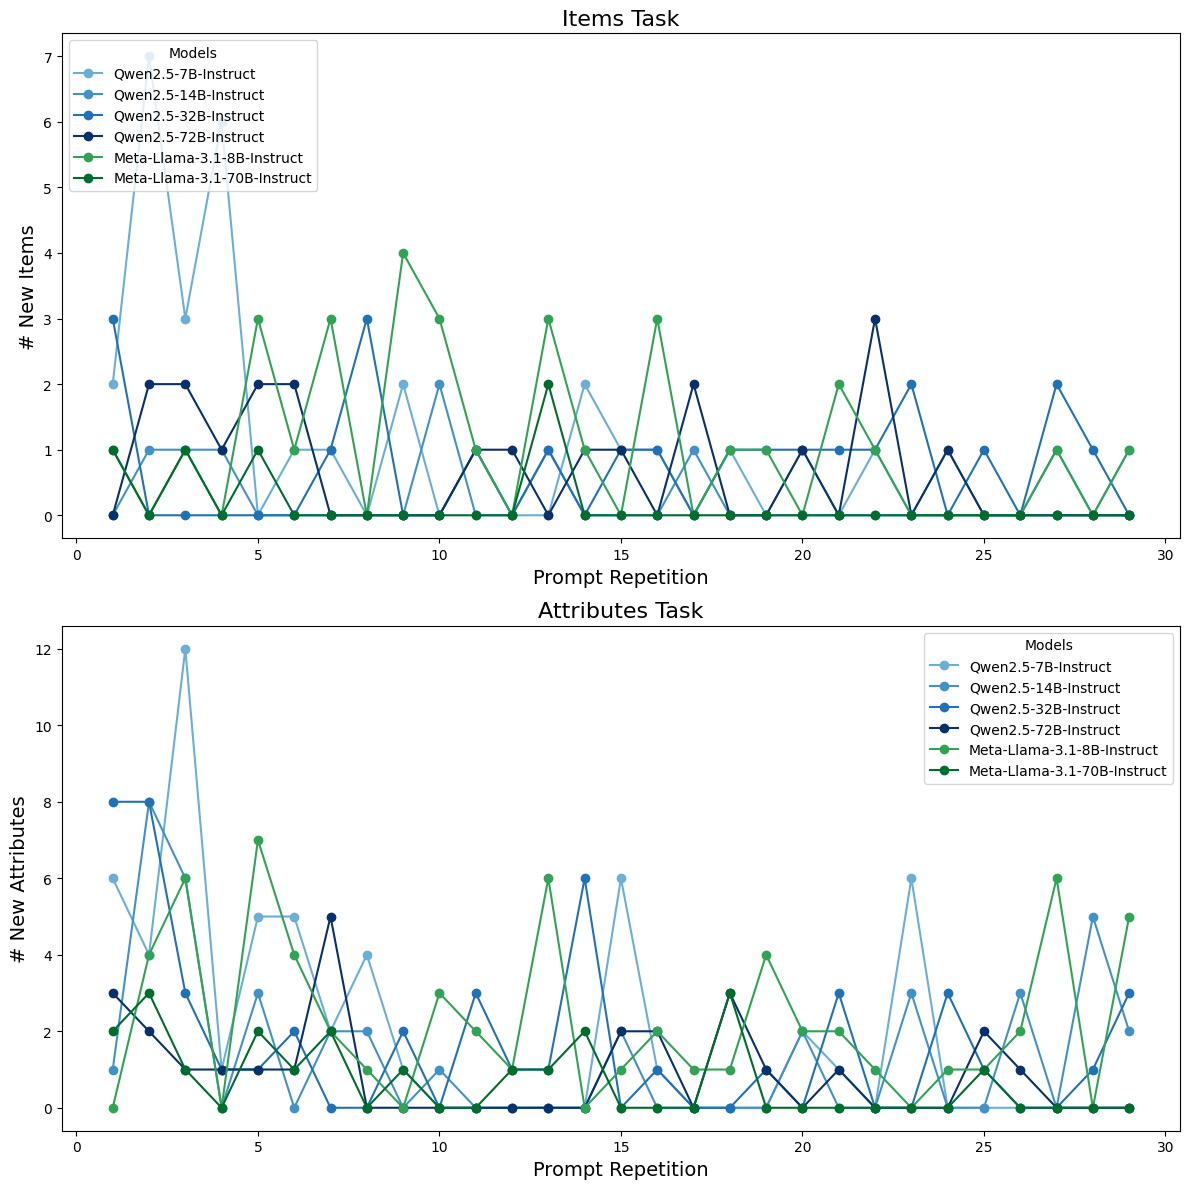

In [1448]:
model_palette = {
    'Qwen2.5-7B-Instruct': '#6baed6',  # Family A
    'Qwen2.5-14B-Instruct': '#4292c6',
    'Qwen2.5-32B-Instruct': '#2171b5',
    'Qwen2.5-72B-Instruct': '#08306b',
    'Meta-Llama-3.1-8B-Instruct': '#31a354',  # Family B (brightened)
    'Meta-Llama-3.1-70B-Instruct': '#006d2c',  # brightened
}

# Counting number of new items/attributes per prompt repetition 
overall_items = []
overall_attributes = []
overall_new_items = []
overall_new_attributes = []

# Filter by prompt ID
filtered_items = items_df[items_df['prompt_id'] == "6"]
filtered_attributes = attributes_df[attributes_df['prompt_id'] == "6"]

# Exclude the specified models
models = [model for model in models if model not in ['gemini-3-pro', 'deepseek-r1-0528']]

for model in models:
    new_items_count = []
    new_attributes_count = []

    outputs_items = filtered_items[filtered_items['model'] == model]['output']
    outputs_attributes = filtered_attributes[filtered_attributes['model'] == model]['output']
    
    for output in outputs_items:
        items = [item.strip() for item in output.split(",")]
        new_items = [item for item in items if item not in overall_items]
        overall_items.extend(new_items)
        new_items_count.append(len(new_items))
    
    for output in outputs_attributes:
        attributes = ([attribute.strip() for attribute in output.split(",")] if isinstance(output, str) else [])
        new_attributes = [attribute for attribute in attributes if attribute not in overall_attributes]
        overall_attributes.extend(new_attributes)
        new_attributes_count.append(len(new_attributes))

    overall_new_items.append(new_items_count)
    overall_new_attributes.append(new_attributes_count)

items_df_new = pd.DataFrame(overall_new_items, index=models)
items_df_new = items_df_new.drop(columns=0, errors='ignore')  # drop repetition 0 
attributes_df_new = pd.DataFrame(overall_new_attributes, index=models)
attributes_df_new = attributes_df_new.drop(columns=0, errors='ignore')  # drop repetition 0 

print("\nItems DataFrame:", items_df_new)
print("\nAttributes DataFrame:", attributes_df_new)

# Plotting
fig, axs = plt.subplots(2, 1, figsize=(12, 12))  # Increased width for better visibility

# Plot New Items
for model in items_df_new.index:
    axs[0].plot(items_df_new.columns, items_df_new.loc[model], marker='o', label=model, color=model_palette.get(model, 'grey'))
axs[0].set_xlabel('Prompt Repetition', fontsize=14) 
axs[0].set_ylabel('# New Items', fontsize=14)  
axs[0].set_title('Items Task', fontsize=16)  
axs[0].legend(title='Models', loc='upper left')

# Plot New Attributes
for model in attributes_df_new.index:
    axs[1].plot(attributes_df_new.columns, attributes_df_new.loc[model], marker='o', label=model, color=model_palette.get(model, 'grey'))
axs[1].set_xlabel('Prompt Repetition', fontsize=14) 
axs[1].set_ylabel('# New Attributes', fontsize=14)  
axs[1].set_title('Attributes Task', fontsize=16)  
axs[1].legend(title='Models', loc='upper right')

plt.tight_layout()
plt.show()

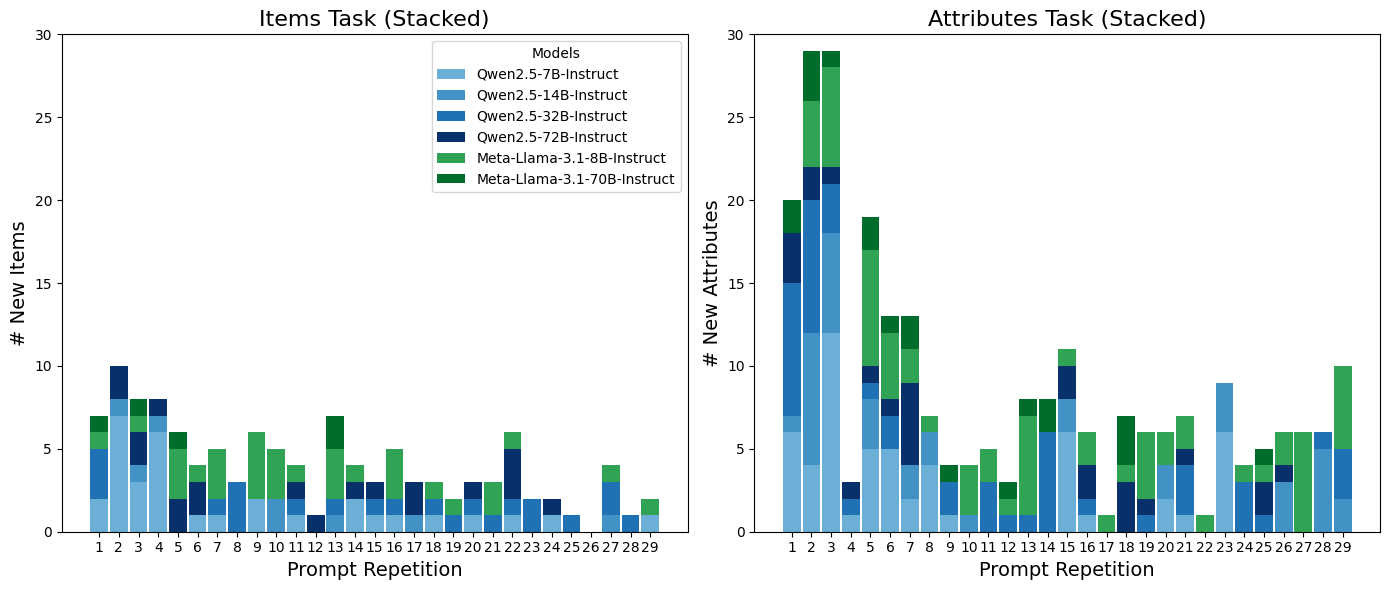

In [ ]:
# Plotting (1 row, 2 columns)
fig, axs = plt.subplots(1, 2, figsize=(14, 6))


x_items = np.arange(len(items_df_new.columns))
x_attributes = np.arange(len(attributes_df_new.columns))

bar_width = 0.9  

bottom_items = np.zeros(len(items_df_new.columns))

for model in items_df_new.index:
    values = items_df_new.loc[model].values
    axs[0].bar(
        x_items,
        values,
        width=bar_width,
        bottom=bottom_items,
        label=model,
        color=model_palette.get(model, 'grey')
    )
    bottom_items += values

axs[0].set_xticks(x_items)
axs[0].set_xticklabels(items_df_new.columns)
axs[0].set_xlabel('Prompt Repetition', fontsize=14)
axs[0].set_ylabel('# New Items', fontsize=14)
axs[0].set_title('Items Task (Stacked)', fontsize=16)
axs[0].set_ylim(0, 30)
axs[0].set_yticks(np.arange(0, 31, 5))
axs[0].legend(title='Models', loc='upper right')


bottom_attributes = np.zeros(len(attributes_df_new.columns))

for model in attributes_df_new.index:
    values = attributes_df_new.loc[model].values
    axs[1].bar(
        x_attributes,
        values,
        width=bar_width,
        bottom=bottom_attributes,
        label=model,
        color=model_palette.get(model, 'grey')
    )
    bottom_attributes += values

axs[1].set_xticks(x_attributes)
axs[1].set_xticklabels(attributes_df_new.columns)
axs[1].set_xlabel('Prompt Repetition', fontsize=14)
axs[1].set_ylabel('# New Attributes', fontsize=14)
axs[1].set_title('Attributes Task (Stacked)', fontsize=16)
axs[1].set_ylim(0, 30)
axs[1].set_yticks(np.arange(0, 31, 5))
#axs[1].legend(title='Models', loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Counting number of new items and attributes per prompt repetition
overall_items = []
overall_attributes = []
overall_new_items = []
overall_new_attributes = []

models = ['Model1', 'Model2', 'Model3']  

filtered_items = items_df[items_df['prompt_id'] == "6"]
filtered_attributes = attributes_df[attributes_df['prompt_id'] == "6"]

for model in models:
    new_items_count = []
    new_attributes_count = []

    outputs_items = filtered_items[filtered_items['model'] == model]['output']
    outputs_attributes = filtered_attributes[filtered_attributes['model'] == model]['output']
    
    for output in outputs_items:
        items = [item.strip() for item in output.split(",")]
        new_items = [item for item in items if item not in overall_items]
        overall_items.extend(new_items)
        new_items_count.append(len(new_items))
    
    for output in outputs_attributes:
        attributes = ([attribute.strip() for attribute in output.split(",")] if isinstance(output, str) else [])
        new_attributes = [attribute for attribute in attributes if attribute not in overall_attributes]
        overall_attributes.extend(new_attributes)
        new_attributes_count.append(len(new_attributes))

    overall_new_items.append(new_items_count)
    overall_new_attributes.append(new_attributes_count)

items_df_new = pd.DataFrame(overall_new_items, index=models)
items_df_new = items_df_new.drop(columns=0, errors='ignore')  # drop repetition 0 
attributes_df_new = pd.DataFrame(overall_new_attributes, index=models)
attributes_df_new = attributes_df_new.drop(columns=0, errors='ignore')  # drop repetition 0 

print("\nItems DataFrame:", items_df_new)
print("\nAttributes DataFrame:", attributes_df_new)

# Plotting
fig, axs = plt.subplots(2, 1, figsize=(12, 12))

# Plot New Items
for model in items_df_new.index:
    axs[0].plot(items_df_new.columns, items_df_new.loc[model], marker='o', label=model)
axs[0].set_xlabel('Prompt Repetition', fontsize=14)
axs[0].set_ylabel('# New Items', fontsize=14)
axs[0].set_title('Items Task', fontsize=16)
axs[0].legend(title='Models', loc='upper left')
axs[0].set_yscale('log')  

# Plot New Attributes
for model in attributes_df_new.index:
    axs[1].plot(attributes_df_new.columns, attributes_df_new.loc[model], marker='o', label=model)
axs[1].set_xlabel('Prompt Repetition', fontsize=14)
axs[1].set_ylabel('# New Attributes', fontsize=14)
axs[1].set_title('Attributes Task', fontsize=16)
axs[1].legend(title='Models', loc='upper right')
axs[1].set_yscale('log') 

plt.tight_layout()
plt.show()


In [1451]:
print("Overall (unique) items generated for category 'furniture': ", len(overall_items))
print("Overall (unique) attributes generated for category item 'desk': ", len(overall_attributes))

Overall (unique) items generated for category 'furniture':  0
Overall (unique) attributes generated for category item 'desk':  0


C:\Users\AS\AppData\Local\Temp\ipykernel_5092\626580486.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[i].set_xticklabels(items[start_index:end_index], fontsize=6, rotation=90)
C:\Users\AS\AppData\Local\Temp\ipykernel_5092\626580486.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[i].set_xticklabels(items[start_index:end_index], fontsize=6, rotation=90)
C:\Users\AS\AppData\Local\Temp\ipykernel_5092\626580486.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[i].set_xticklabels(items[start_index:end_index], fontsize=6, rotation=90)
C:\Users\AS\AppData\Local\Temp\ipykernel_5092\626580486.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocat

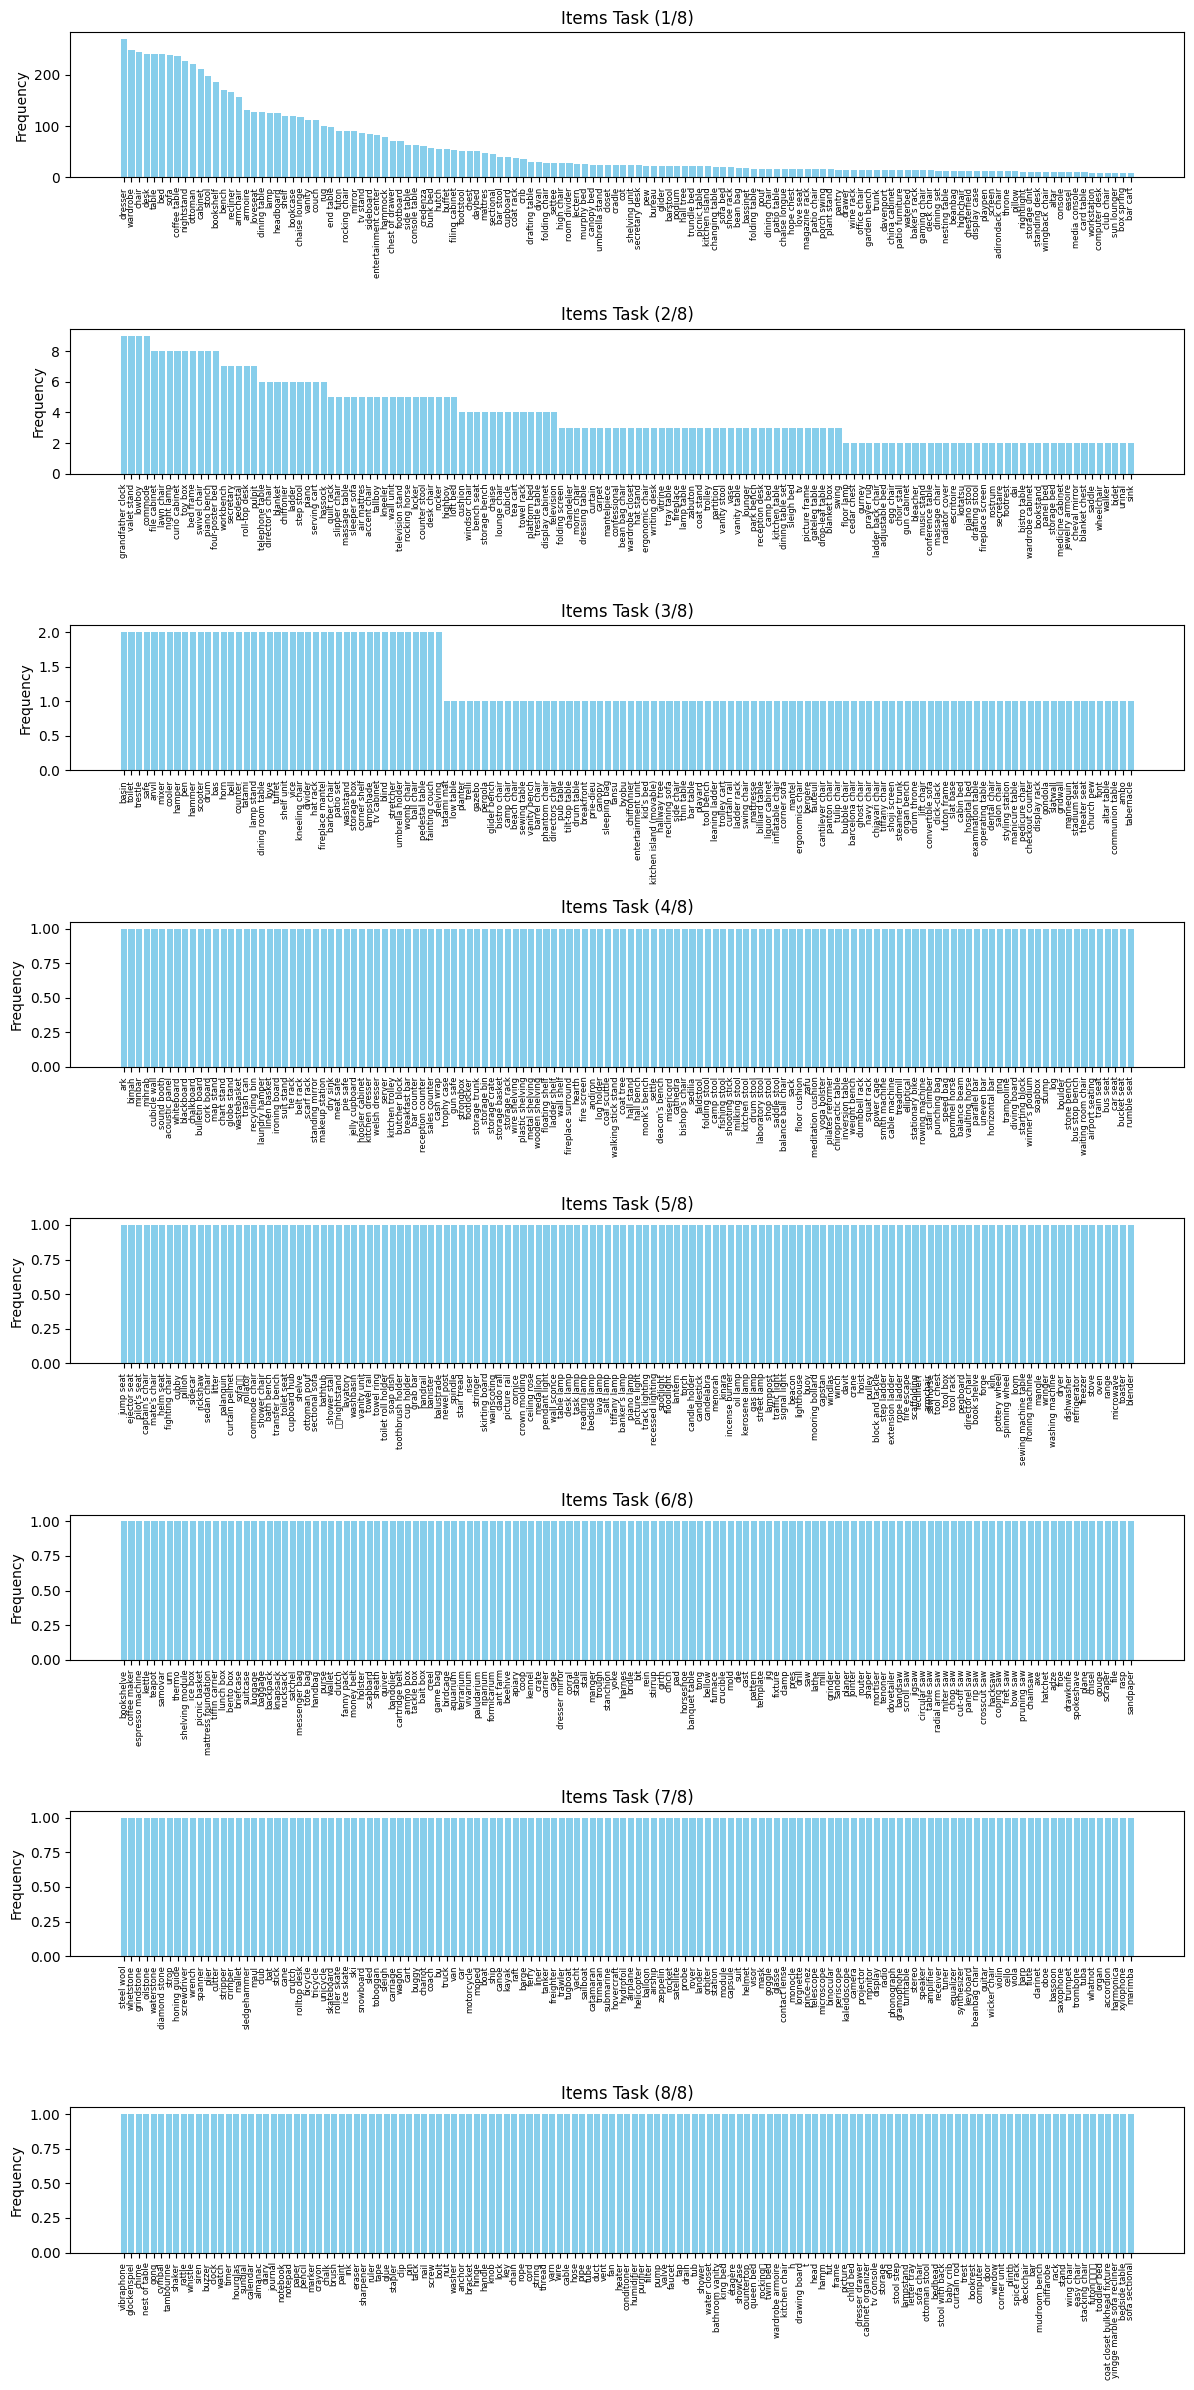

In [ ]:
# Plotting Frequency for each generated Item

all_items = []

for index, row in items_df.iterrows():
    items_list = row['output'].split(",")
    all_items.extend(item.strip() for item in items_list)

items_counts = pd.Series(all_items).value_counts()

# Plot
fig, axs = plt.subplots(8, 1, figsize=(12, 24))  

items = items_counts.index
counts = items_counts.values
eighth_size = len(items) // 8  

for i in range(8):
    start_index = i * eighth_size
    end_index = (i + 1) * eighth_size if i < 7 else len(items)
    
    axs[i].bar(items[start_index:end_index], counts[start_index:end_index], color='skyblue')
    axs[i].set_ylabel('Frequency')
    axs[i].set_title(f'Items Task ({i + 1}/8)')  
    axs[i].tick_params(axis='x', rotation=90)
    axs[i].set_xticklabels(items[start_index:end_index], fontsize=6, rotation=90)

plt.tight_layout()
plt.show()


C:\Users\AS\AppData\Local\Temp\ipykernel_5092\3939490881.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[i].set_xticklabels(attributes[start_index:end_index], fontsize=6, rotation=90)
C:\Users\AS\AppData\Local\Temp\ipykernel_5092\3939490881.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[i].set_xticklabels(attributes[start_index:end_index], fontsize=6, rotation=90)
C:\Users\AS\AppData\Local\Temp\ipykernel_5092\3939490881.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[i].set_xticklabels(attributes[start_index:end_index], fontsize=6, rotation=90)


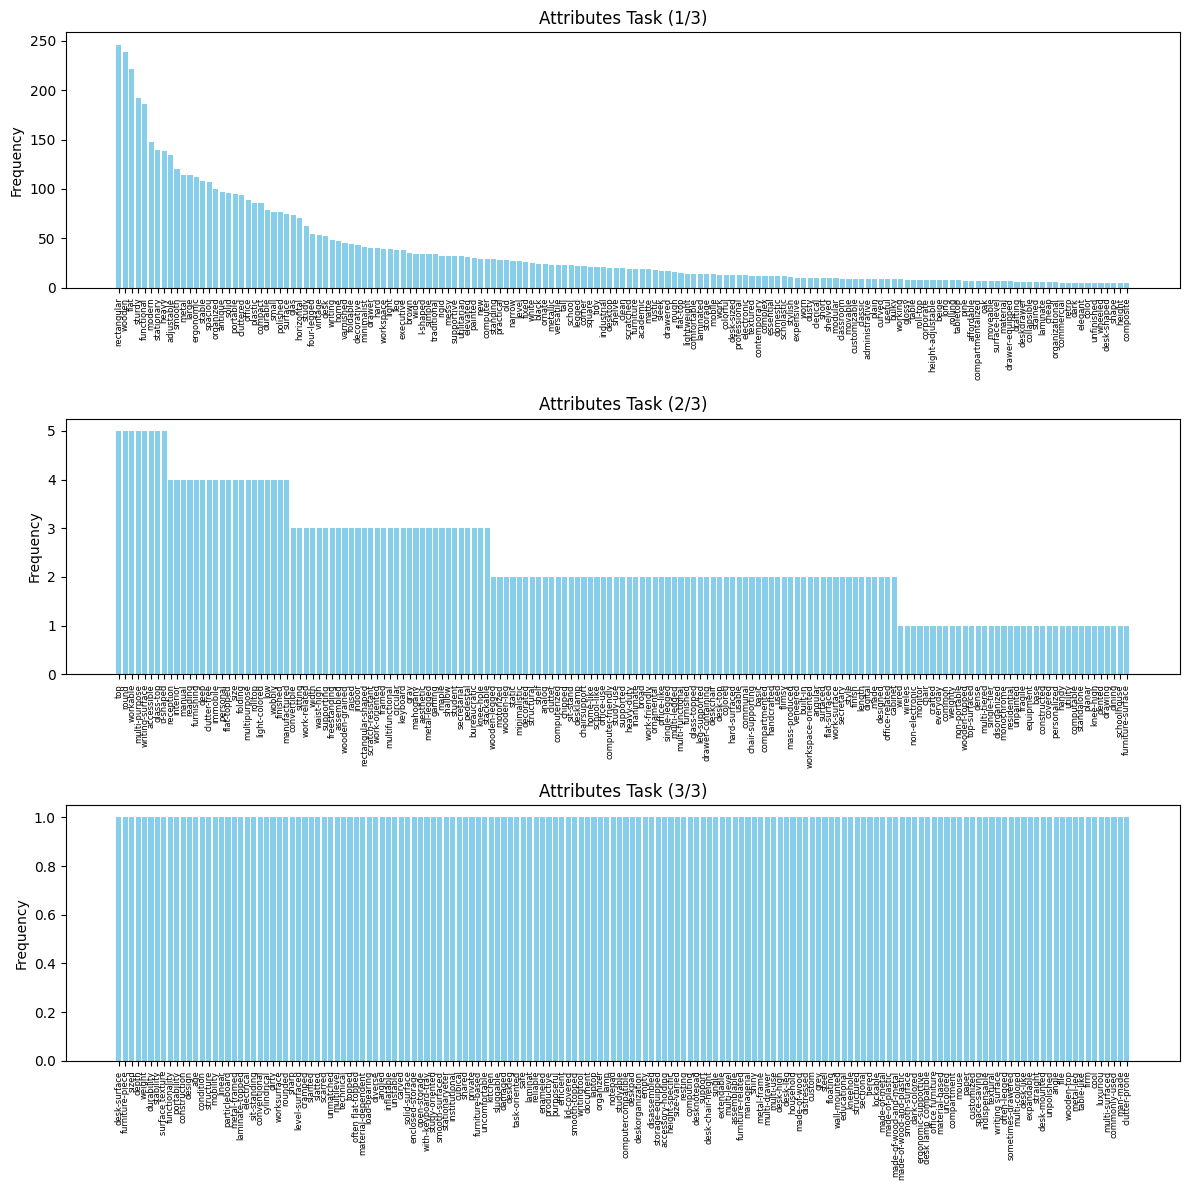

In [ ]:
# Plotting Frequency for each unique generated Attribute

all_attributes = []

for index, row in attributes_df.iterrows():
    if pd.isna(row['output']):
        continue 
    attributes_list = row['output'].split(",")
    all_attributes.extend(attribute.strip() for attribute in attributes_list)

attributes_counts = pd.Series(all_attributes).value_counts()

# Plot
fig, axs = plt.subplots(3, 1, figsize=(12, 12))  

attributes = attributes_counts.index
counts = attributes_counts.values
third_size = len(attributes) // 3  

for i in range(3): 
    start_index = i * third_size
    end_index = (i + 1) * third_size if i < 2 else len(attributes)  
    
    axs[i].bar(attributes[start_index:end_index], counts[start_index:end_index], color='skyblue')
    axs[i].set_ylabel('Frequency')
    axs[i].set_title(f'Attributes Task ({i + 1}/3)')
    axs[i].tick_params(axis='x', rotation=90)
    axs[i].set_xticklabels(attributes[start_index:end_index], fontsize=6, rotation=90)

plt.tight_layout()
plt.show()


#### Pre-experiment 1 outputs processing

In [ ]:
# Get all unique common items between each model's outputs

items_df['output_list'] = items_df['output'].apply(lambda x: x.split(','))

def get_common_items(group):
    lists = group['output_list'].tolist()
    if lists:
        common_items = set(lists[0])  
        for lst in lists[1:]:
            common_items &= set(lst)  
        return list(common_items) 
    return []

result = items_df.groupby('model').apply(get_common_items).reset_index(name='withinmodel_commonitems')

for index, row in result.iterrows():
    print(f"\nModel: {row['model']}")
    print(f"{row['withinmodel_commonitems']}")



Model: Meta-Llama-3.1-70B-Instruct
['bed', 'desk', 'dresser', 'recliner', 'stool', 'table', 'coffee table', 'wardrobe', 'nightstand', 'tv stand', 'bookshelf', 'ottoman', 'chair', 'loveseat']

Model: Meta-Llama-3.1-8B-Instruct
['bed', 'desk', 'dresser', 'table', 'coffee table', 'wardrobe', 'nightstand', 'sofa', 'ottoman', 'chair', 'cabinet', 'bookshelf']

Model: Qwen2.5-14B-Instruct
['bed', 'desk', 'lamp', 'rug', 'table', 'coffee table', 'sofa', 'wardrobe', 'chair']

Model: Qwen2.5-32B-Instruct
['bed', 'ottoman', 'desk', 'dresser', 'stool', 'table', 'coffee table', 'nightstand', 'sofa', 'wardrobe', 'headboard', 'chair', 'cabinet']

Model: Qwen2.5-72B-Instruct
['bed', 'desk', 'dresser', 'bench', 'recliner', 'dining table', 'table', 'coffee table', 'nightstand', 'sofa', 'ottoman', 'chair', 'cabinet']

Model: Qwen2.5-7B-Instruct
['bed', 'desk', 'table', 'sofa', 'chair']

Model: deepseek-r1-0528
['bed', 'desk', 'dresser', 'bench', 'stool', 'table', 'coffee table', 'wardrobe', 'ottoman', 'c

C:\Users\AS\AppData\Local\Temp\ipykernel_5092\1390871562.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = items_df.groupby('model').apply(get_common_items).reset_index(name='withinmodel_commonitems')


In [1455]:
# Get all unique common items between each model's outputs

items_df['output_list'] = items_df['output'].apply(lambda x: x.split(','))

model_items = items_df.groupby('model')['output_list'].apply(lambda x: [item for sublist in x for item in sublist]).reset_index()
model_items.columns = ['model', 'betweenmodels_commonitems']

common_items = set(model_items['betweenmodels_commonitems'][0])  

for items in model_items['betweenmodels_commonitems'][1:]:
    common_items.intersection_update(items)
common_items_list = list(common_items)

print("Common items across all models:\n", common_items_list)


Common items across all models:
 ['bench', 'nightstand', 'chair', 'armchair', 'couch', 'table', 'sofa', 'wardrobe', 'bed', 'desk', 'shelf', 'coffee table', 'bookshelf', 'end table', 'cabinet', 'sideboard', 'dresser', 'dining table', 'ottoman']


In [1456]:
len(common_items_list)

19

In [1457]:
common_items_list

['bench',
 'nightstand',
 'chair',
 'armchair',
 'couch',
 'table',
 'sofa',
 'wardrobe',
 'bed',
 'desk',
 'shelf',
 'coffee table',
 'bookshelf',
 'end table',
 'cabinet',
 'sideboard',
 'dresser',
 'dining table',
 'ottoman']

C:\Users\AS\AppData\Local\Temp\ipykernel_5092\2542946217.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(items, fontsize=6, rotation=90)


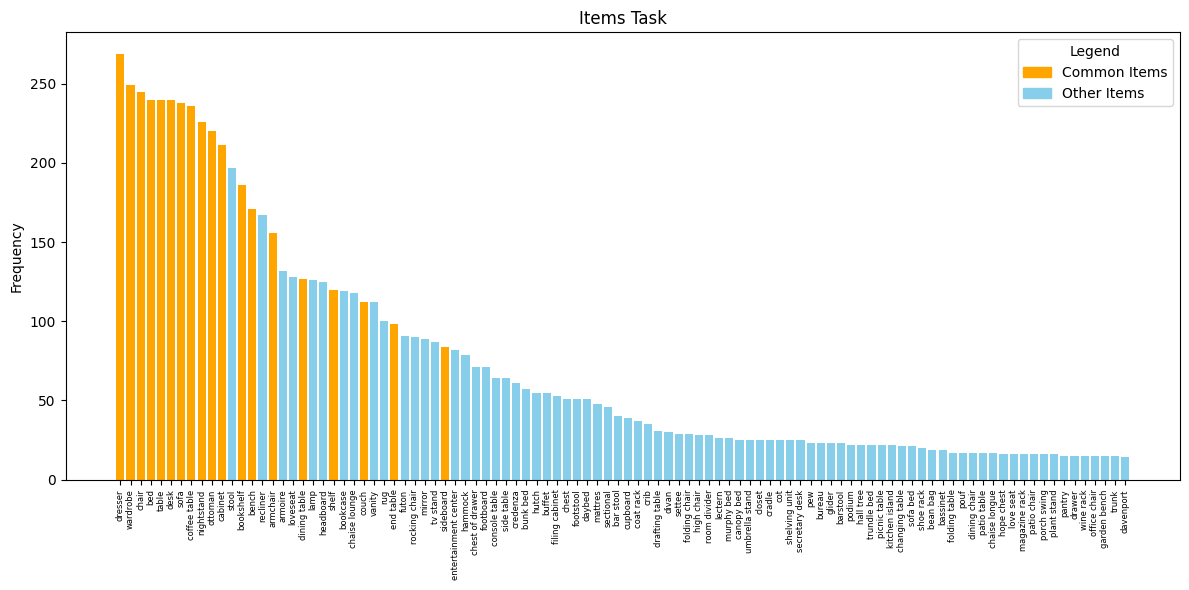

In [ ]:
# Frequency for each of these items in the overall dataframe

all_items = [item for sublist in items_df['output_list'] for item in sublist]
items_counts = pd.Series(all_items).value_counts()

items = items_counts.index[:100]  
counts = items_counts.values[:100]  

# Plotting
fig, ax = plt.subplots(figsize=(12, 6)) 

colors = ['orange' if item in common_items_list else 'skyblue' for item in items]
bars = ax.bar(items, counts, color=colors)
handles = [plt.Rectangle((0, 0), 1, 1, color='orange'), plt.Rectangle((0, 0), 1, 1, color='skyblue')]
labels = ['Common Items', 'Other Items']
ax.legend(handles, labels, title='Legend')
ax.set_ylabel('Frequency')
ax.set_title('Items Task')  
ax.tick_params(axis='x', rotation=90)
ax.set_xticklabels(items, fontsize=6, rotation=90)

plt.tight_layout()
plt.show()


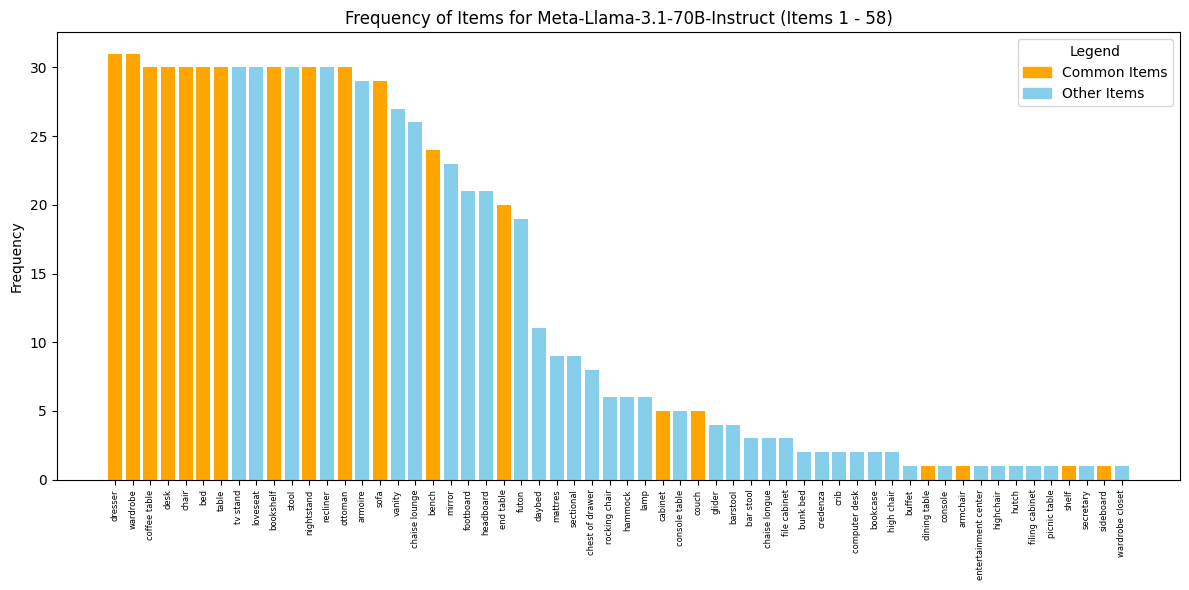

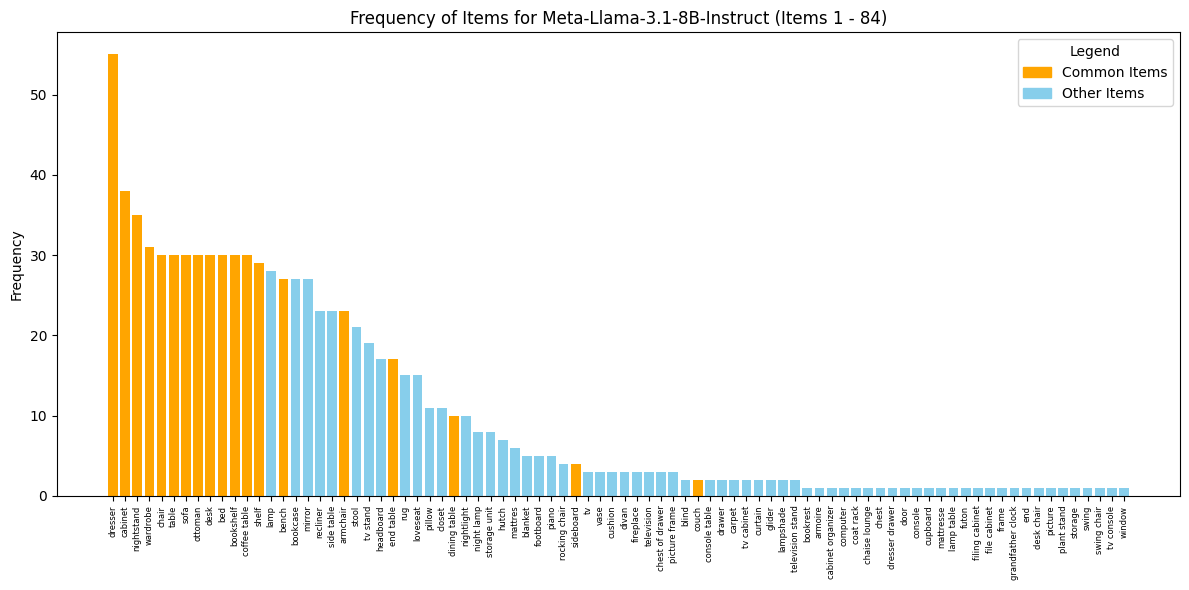

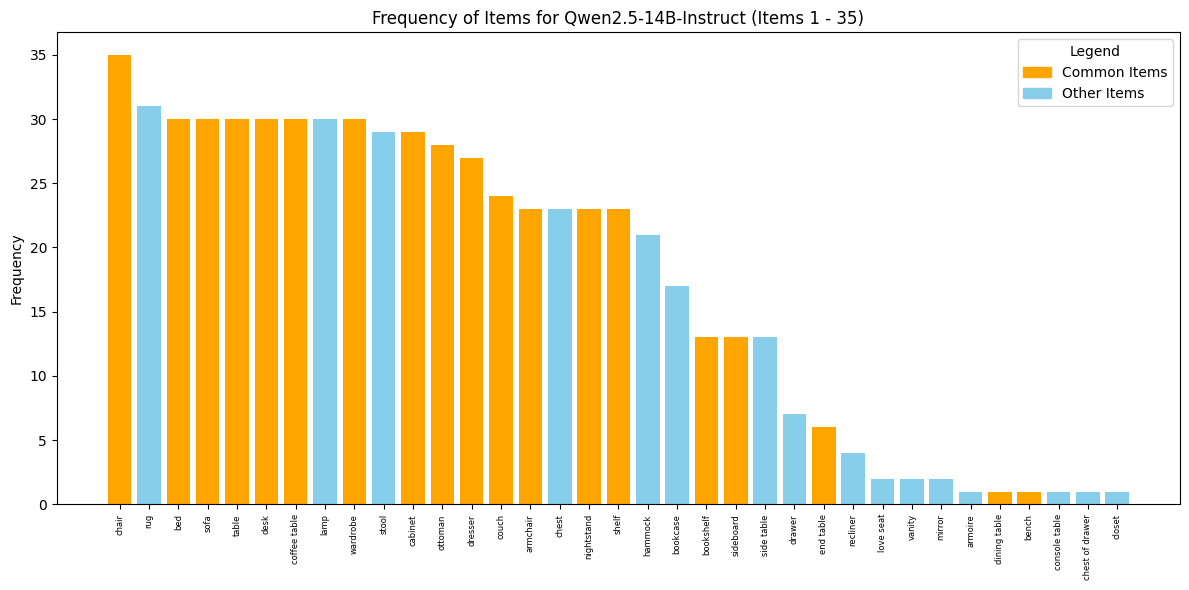

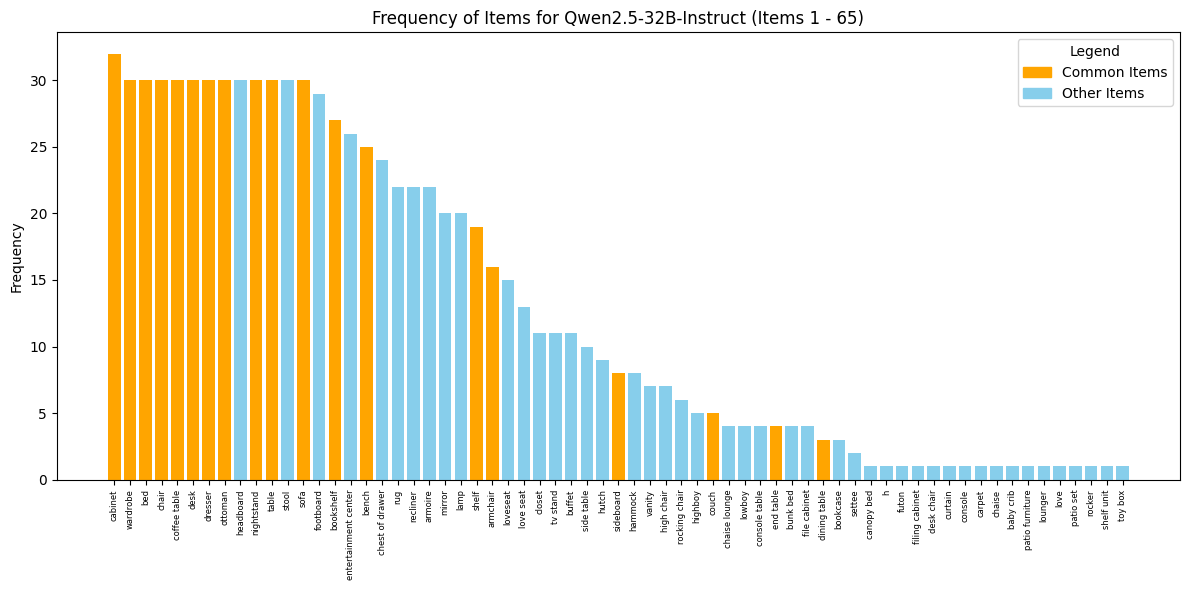

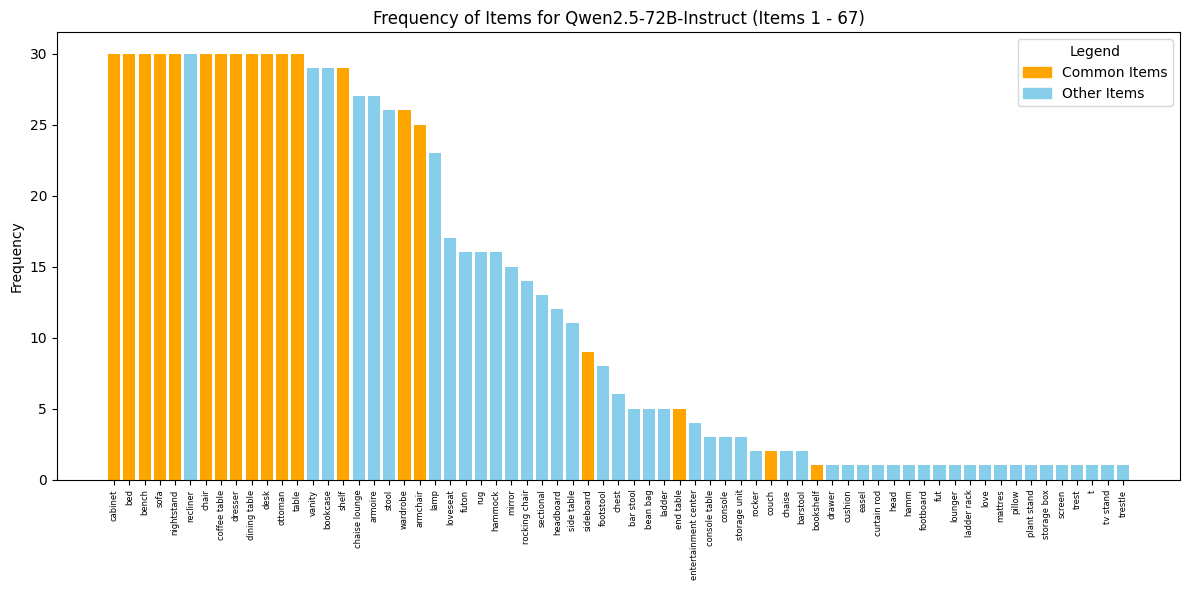

C:\Users\AS\AppData\Local\Temp\ipykernel_5092\74976816.py:36: UserWarning: Glyph 26885 (\N{CJK UNIFIED IDEOGRAPH-6905}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\AS\AppData\Local\Programs\Python\Python310\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26885 (\N{CJK UNIFIED IDEOGRAPH-6905}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


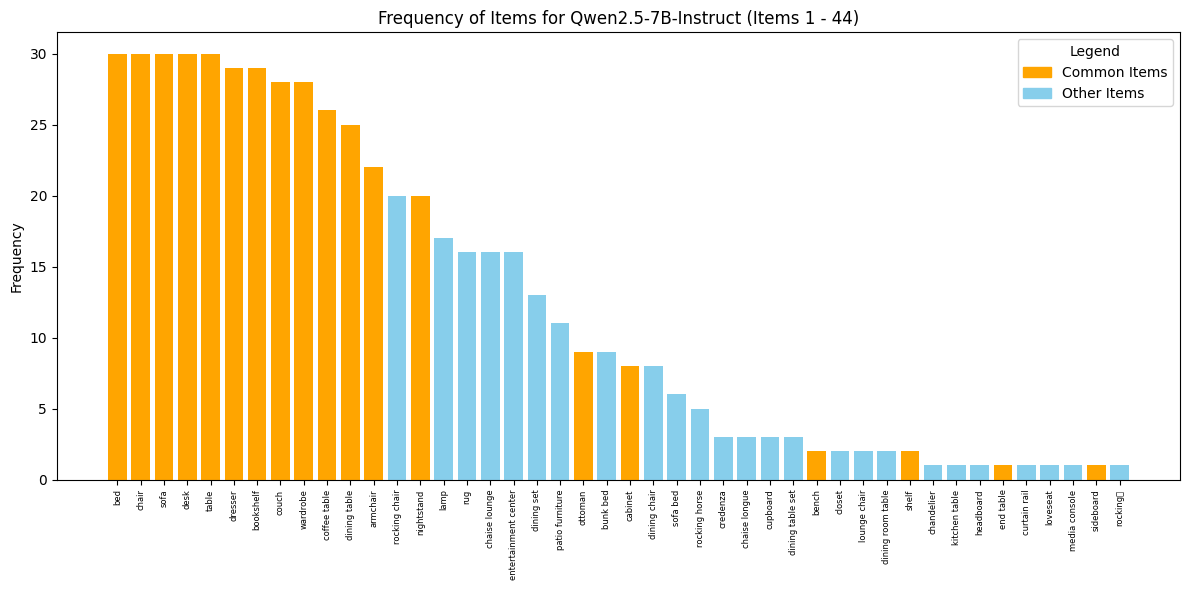

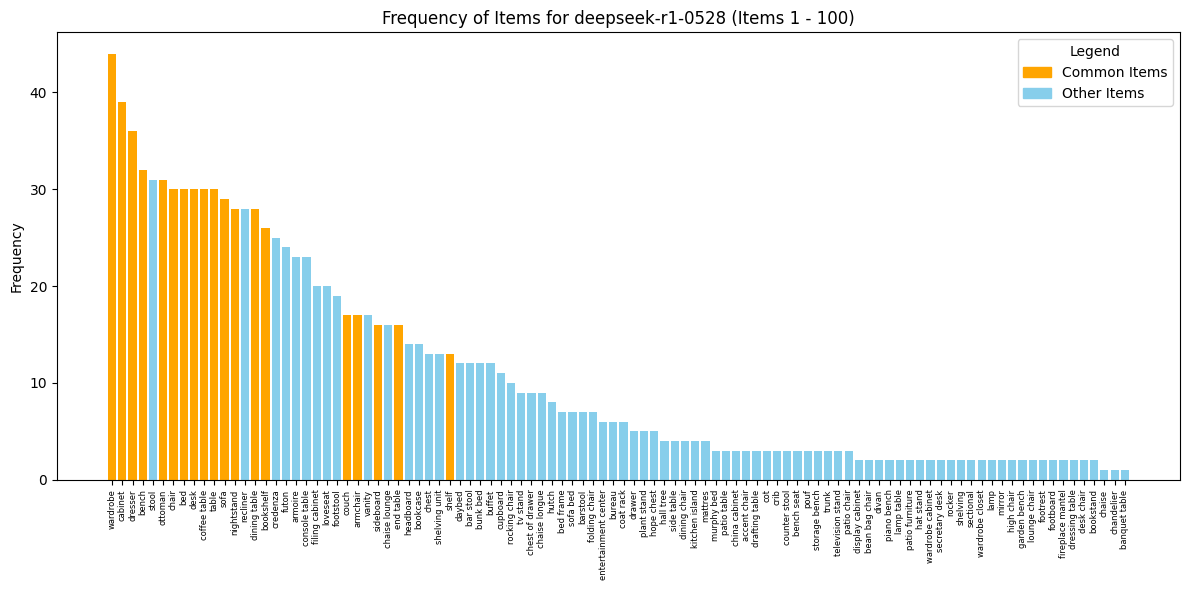

C:\Users\AS\AppData\Local\Temp\ipykernel_5092\74976816.py:36: UserWarning: Glyph 28145 (\N{CJK UNIFIED IDEOGRAPH-6DF1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\AS\AppData\Local\Temp\ipykernel_5092\74976816.py:36: UserWarning: Glyph 22812 (\N{CJK UNIFIED IDEOGRAPH-591C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\AS\AppData\Local\Temp\ipykernel_5092\74976816.py:36: UserWarning: Glyph 20027 (\N{CJK UNIFIED IDEOGRAPH-4E3B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\AS\AppData\Local\Temp\ipykernel_5092\74976816.py:36: UserWarning: Glyph 25773 (\N{CJK UNIFIED IDEOGRAPH-64AD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\AS\AppData\Local\Temp\ipykernel_5092\74976816.py:36: UserWarning: Glyph 29699 (\N{CJK UNIFIED IDEOGRAPH-7403}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\AS\AppData\Local\Temp\ipykernel_5092\74976816.py:36: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missi

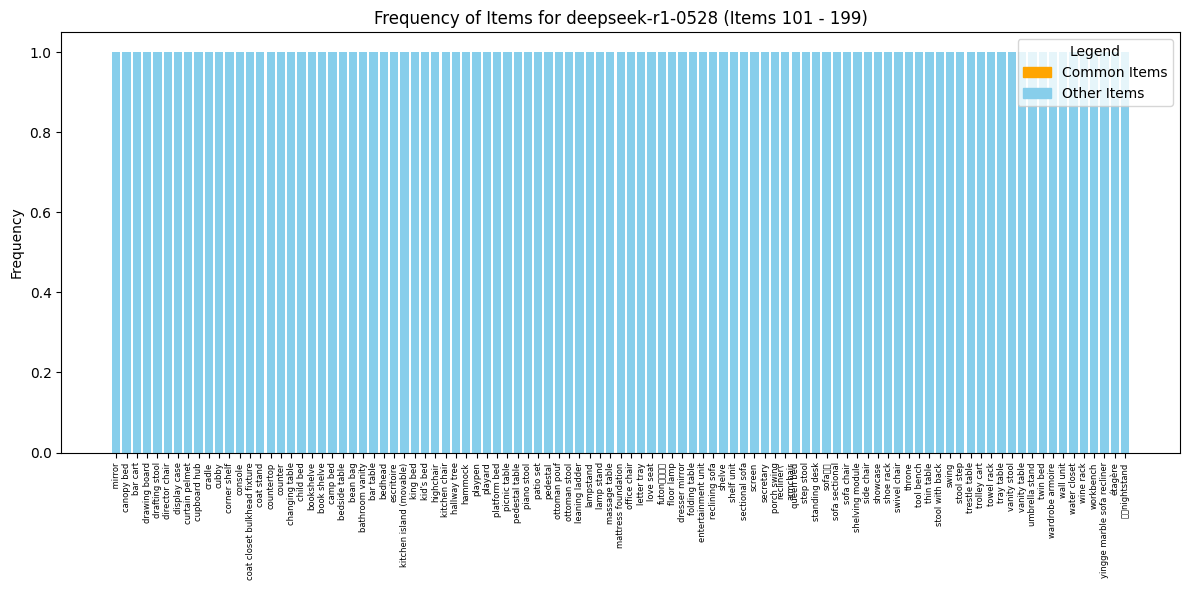

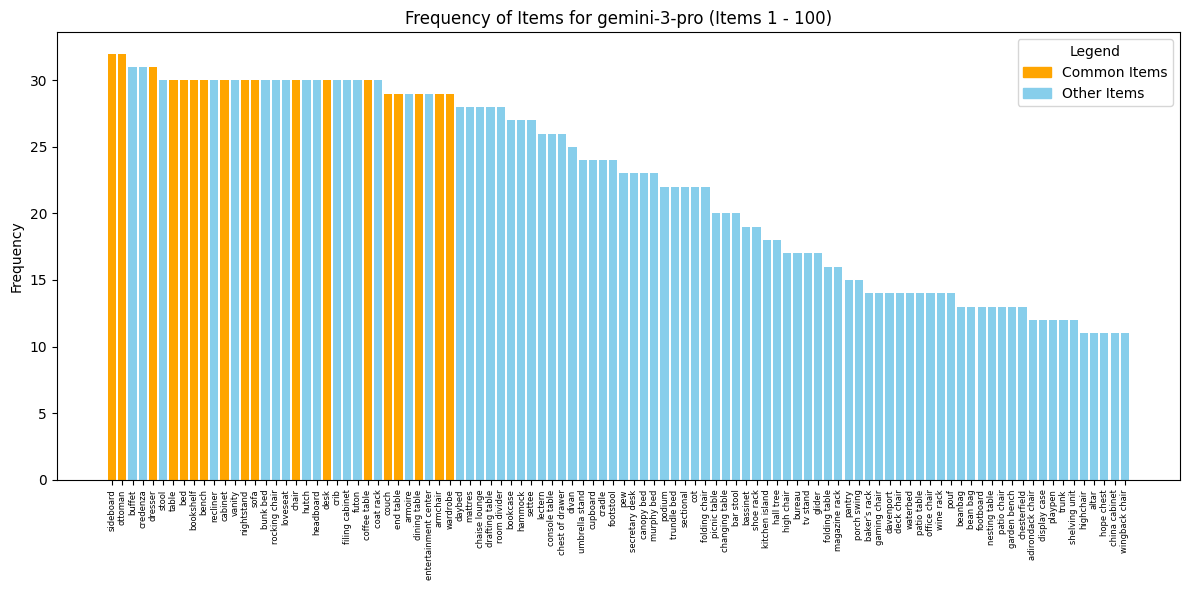

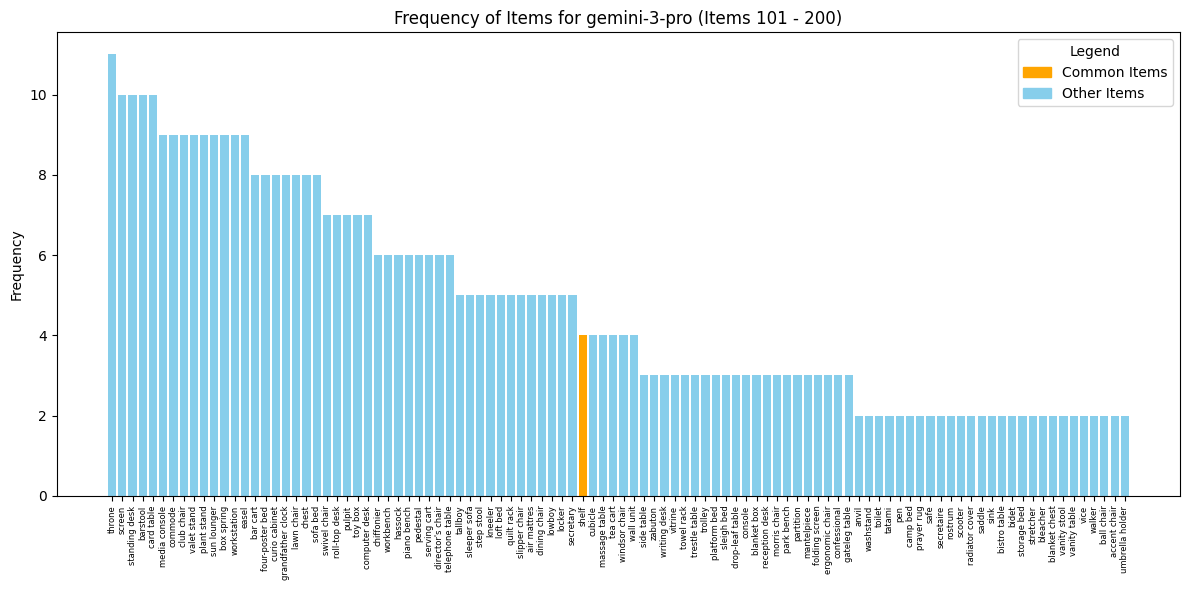

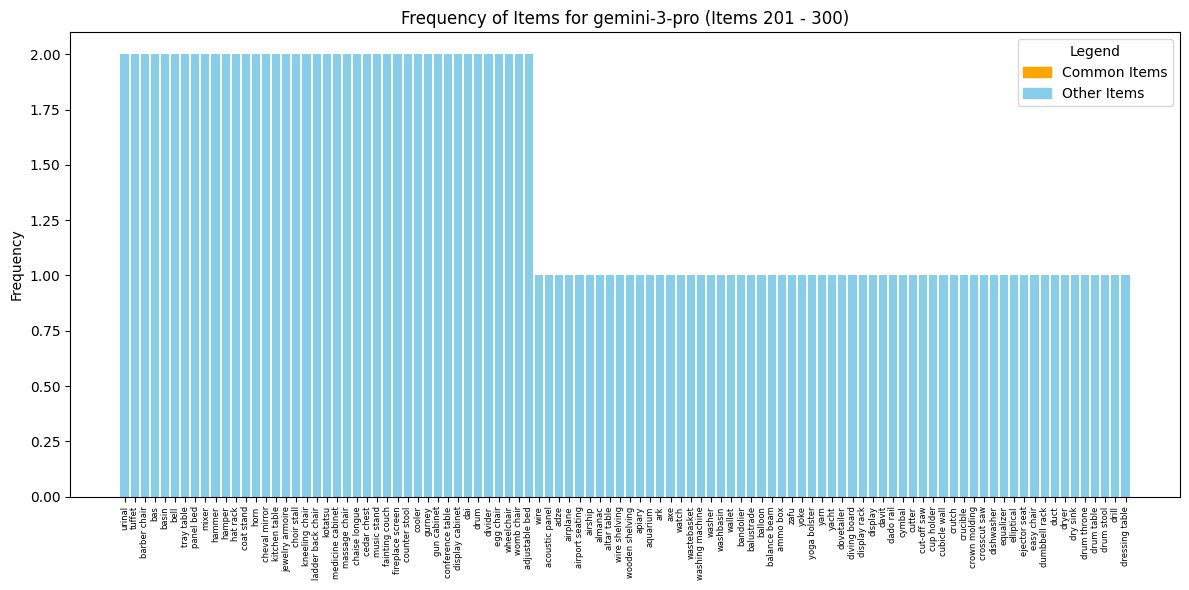

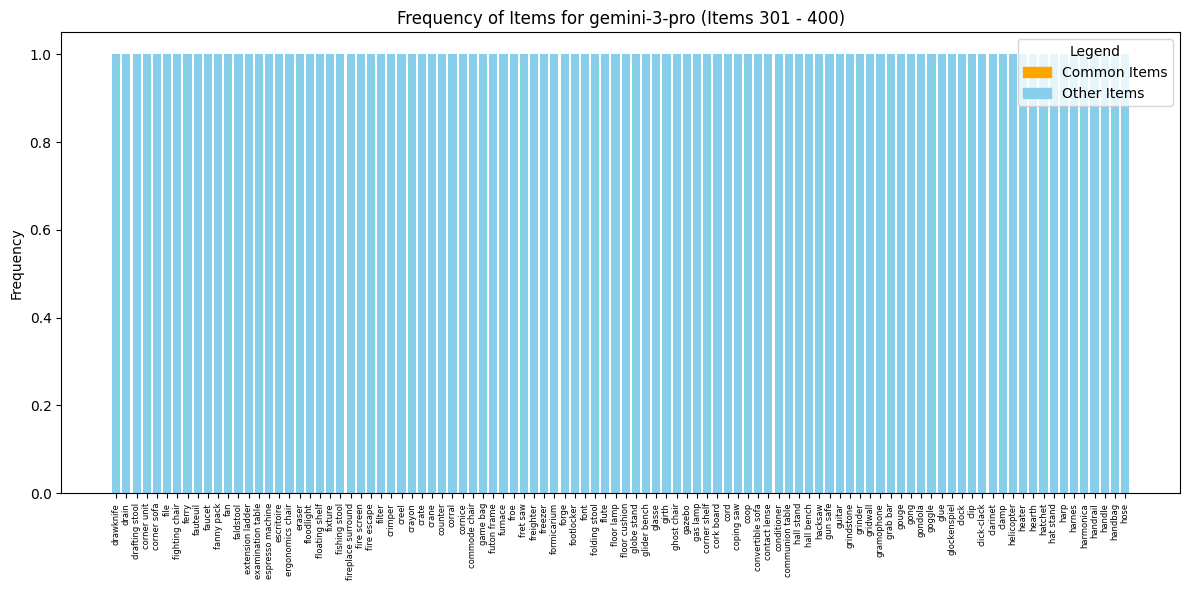

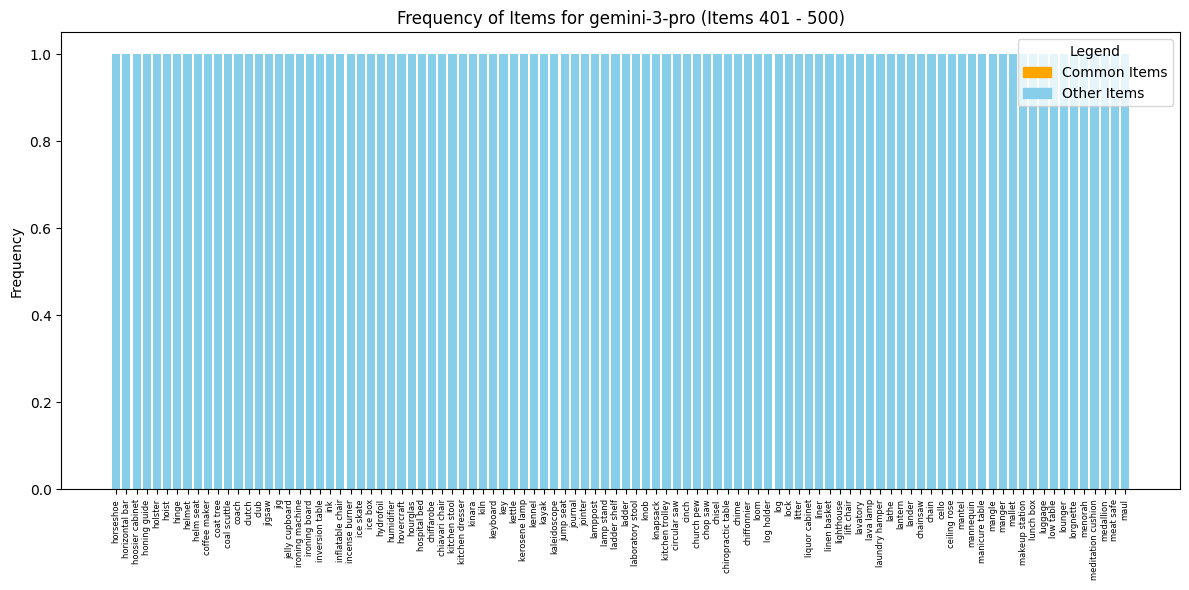

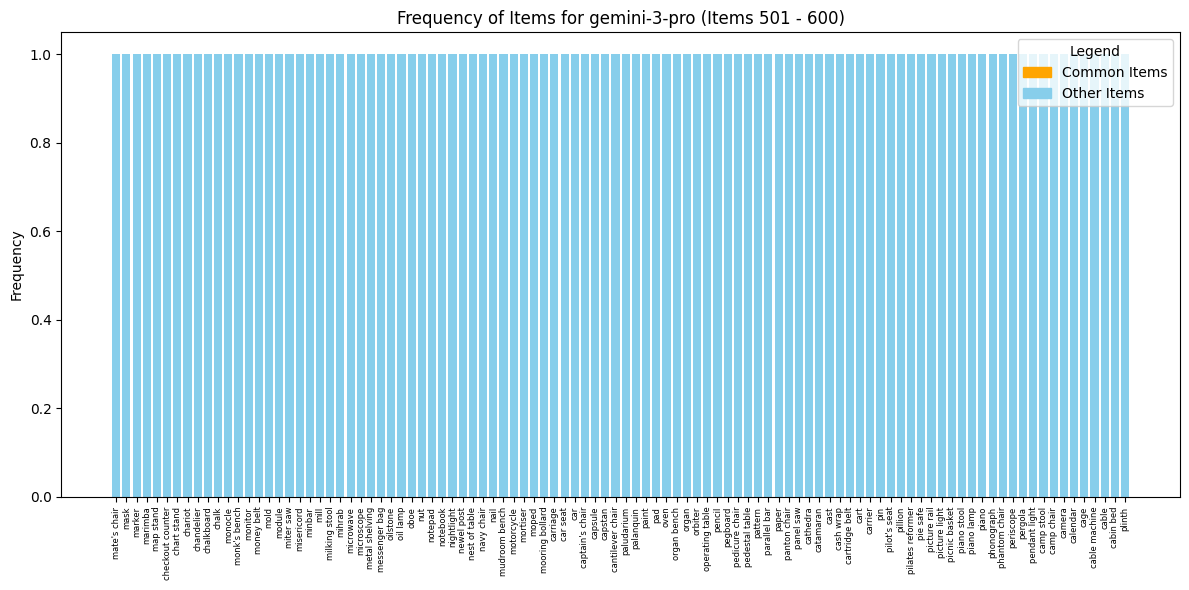

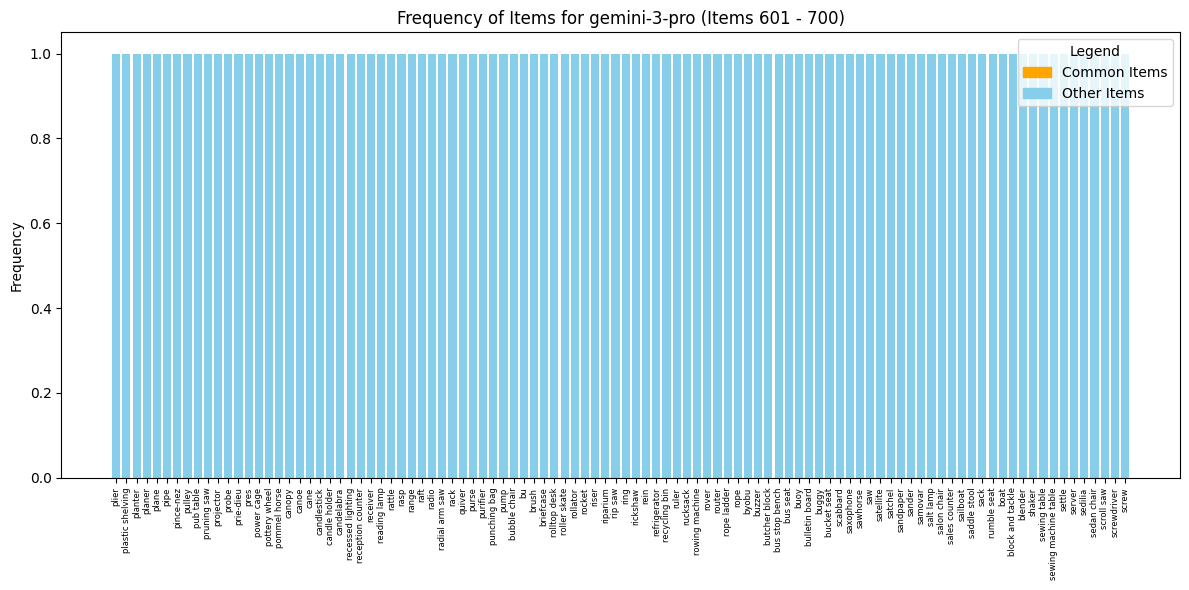

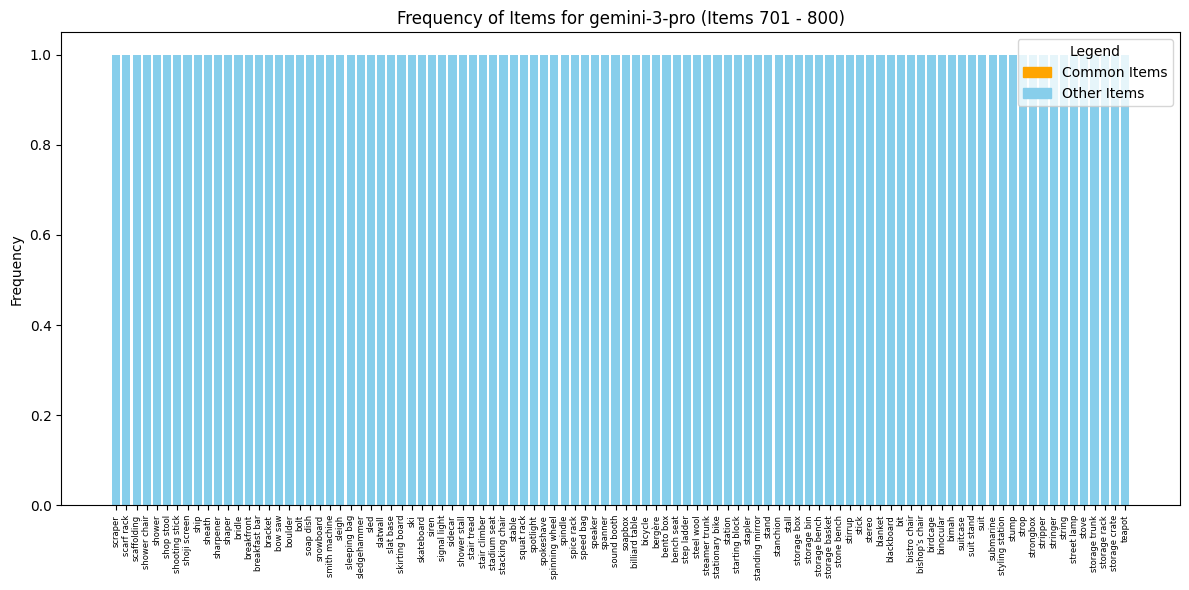

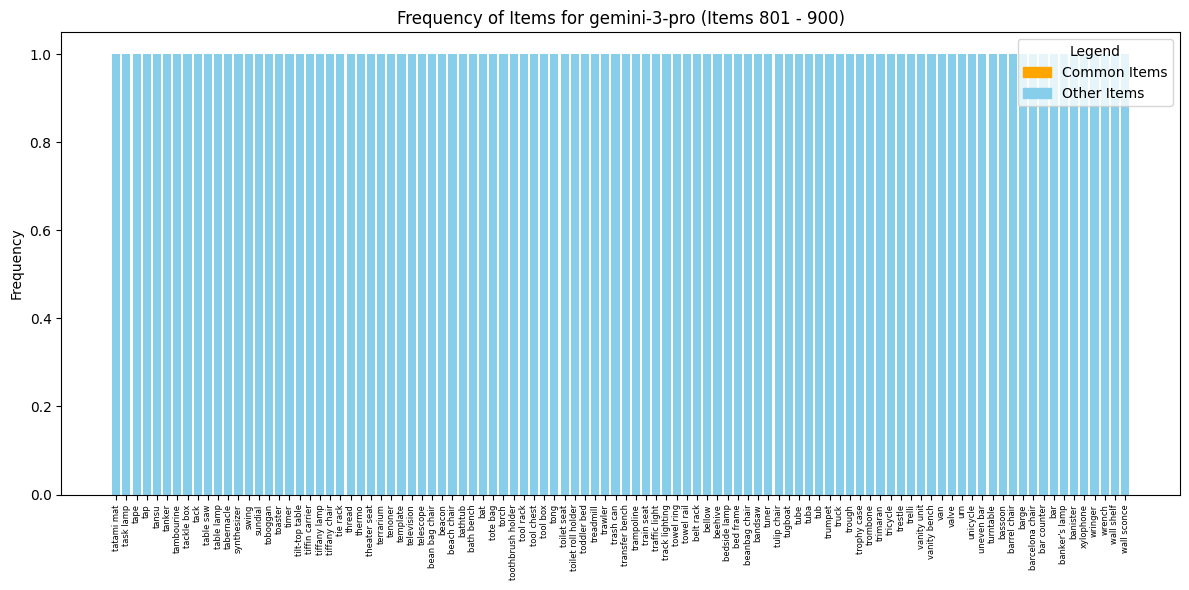

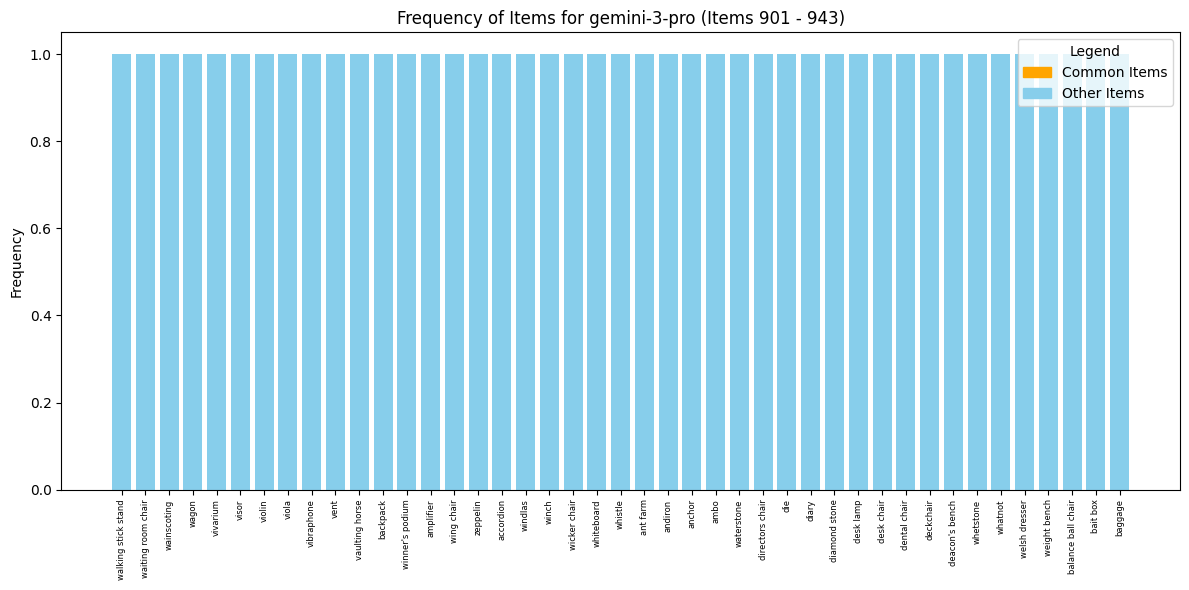

In [1459]:
# Plotting for each model the frequency count for items

model_items = items_df.explode('output_list') 
item_counts = model_items.groupby(['model', 'output_list']).size().reset_index(name='frequency')

common_items = set(items_df['output_list'].explode().tolist())
for model in items_df['model'].unique():
    model_specific_items = set(item_counts[item_counts['model'] == model]['output_list'])
    common_items.intersection_update(model_specific_items)

# Plotting
items_per_subplot = 100
unique_models = item_counts['model'].unique()

for model in unique_models:
   
    model_data = item_counts[item_counts['model'] == model]
    model_data = model_data.sort_values(by='frequency', ascending=False)
    

    n_subplots = (len(model_data) // items_per_subplot) + (1 if len(model_data) % items_per_subplot > 0 else 0)
    for subplot_index in range(n_subplots):
        plt.figure(figsize=(12, 6))

        current_data = model_data.iloc[subplot_index * items_per_subplot:(subplot_index + 1) * items_per_subplot]

        colors = ['orange' if item in common_items else 'skyblue' for item in current_data['output_list']]
        bars = plt.bar(current_data['output_list'], current_data['frequency'], color=colors)
        plt.title(f'Frequency of Items for {model} (Items {subplot_index * items_per_subplot + 1} - {min((subplot_index + 1) * items_per_subplot, len(model_data))})')
        plt.ylabel('Frequency')
        plt.xticks(current_data['output_list'], fontsize=6, rotation=90)
        handles = [plt.Rectangle((0, 0), 1, 1, color='orange'), plt.Rectangle((0, 0), 1, 1, color='skyblue')]
        labels = ['Common Items', 'Other Items']
        plt.legend(handles, labels, title='Legend')
        
        plt.tight_layout()
        plt.show()


In [1460]:
# Common Items
common_items_list

# Rosch Furniture List
rosch1975c_furniture = ["chair", "sofa", "table", "dresser", "desk", "bed", "bookcase", "footstool", "lamp", "piano", "cushion", "mirror", "rug", "radio", "stove", "clock", "picture", "closet", "vase", "telephone"]

In [ ]:
# Selecting items for attributes-task for each model

model_items = items_df.explode('output_list') 
item_counts = model_items.groupby(['model', 'output_list']).size().reset_index(name='frequency')

results = {}
for model in item_counts['model'].unique():
    model_data = item_counts[item_counts['model'] == model]
    
    model_data = model_data.sort_values(by='frequency', ascending=False)
    min_freq, max_freq = model_data['frequency'].min(), model_data['frequency'].max()
    range_1 = model_data[(model_data['frequency'] <= (1/3) * max_freq)]
    range_2 = model_data[(model_data['frequency'] > (1/3) * max_freq) & (model_data['frequency'] <= (2/3) * max_freq)]
    range_3 = model_data[(model_data['frequency'] > (2/3) * max_freq)]

    results[model] = {
        'Range 1': range_1.head(5).reset_index(drop=True),
        'Range 2': range_2.head(5).reset_index(drop=True),
        'Range 3': range_3.head(5).reset_index(drop=True)
    }

# Print results
for model, ranges in results.items():
    print(f"\nModel: {model}")
    for range_name, items in ranges.items():
        print(f"{range_name}:\n{items[['output_list', 'frequency']]}")


Model: Meta-Llama-3.1-70B-Instruct
Range 1:
       output_list  frequency
0          mattres          9
1        sectional          9
2  chest of drawer          8
3    rocking chair          6
4          hammock          6
Range 2:
  output_list  frequency
0   end table         20
1       futon         19
2      daybed         11
Range 3:
    output_list  frequency
0       dresser         31
1      wardrobe         31
2  coffee table         30
3          desk         30
4         chair         30

Model: Meta-Llama-3.1-8B-Instruct
Range 1:
  output_list  frequency
0   headboard         17
1   end table         17
2         rug         15
3    loveseat         15
4      pillow         11
Range 2:
  output_list  frequency
0  nightstand         35
1    wardrobe         31
2       chair         30
3       table         30
4        sofa         30
Range 3:
  output_list  frequency
0     dresser         55
1     cabinet         38

Model: Qwen2.5-14B-Instruct
Range 1:
  output_list  frequ

In [ ]:
# Stratified Sampling of Items for Attributes Task

rosch_furniture_set = set(rosch1975c_furniture)

# Function for stratified sampling
def prioritize_items(range_items, common_items, rosch_furniture_set):

    selected_items = range_items[range_items['output_list'].isin(common_items)]
    
    rosch_selected_items = selected_items[selected_items['output_list'].isin(rosch_furniture_set)]
    rosch_items = range_items[range_items['output_list'].isin(rosch_furniture_set)]

    if len(selected_items) >= 6:
        if len(rosch_selected_items) == 0:
            
            to_replace = selected_items.sample(min(len(selected_items), 3)).index
            selected_items = selected_items.drop(to_replace)
            selected_items = pd.concat([selected_items, rosch_items.head(3)], axis=0)
    else:
        if len(selected_items) < 6:
            additional_items_needed = 6 - len(selected_items)
            selected_items = pd.concat([selected_items, rosch_items], axis=0)

            if len(selected_items) < 6:
                remaining_items_needed = 6 - len(selected_items)
                random_items = range_items.sample(n=remaining_items_needed).reset_index(drop=True)
                selected_items = pd.concat([selected_items, random_items], axis=0)

    return selected_items.head(6).reset_index(drop=True)

# Print Results
for model, ranges in results.items():
    print(f"\nModel: {model}")

    for range_name, items in ranges.items():
        common_items = item_counts['output_list'].unique()
        prioritized_items = prioritize_items(items, common_items, rosch_furniture_set)
        output_list = prioritized_items[['output_list', 'frequency']].values.tolist()
        item_frequencies = ", ".join([f"{item[0]} (Frequency: {item[1]})" for item in output_list])
        print(f"{range_name}: [{item_frequencies}]")

In [ ]:
# Function to create the visualization table

def create_visualization_table(results, rosch_furniture_set, common_items, range_items):

    unique_items = set()

    for model, items in range_items.items():
        unique_items.update(items['output_list'].unique())

    visualization_df = pd.DataFrame(index=sorted(unique_items))

    for model in results.keys():
        if model in range_items:
            combined_items = range_items[model]['output_list']
            visualization_df[model] = np.where(visualization_df.index.isin(combined_items), '✔', '')

    visualization_df['Rosch'] = np.where(visualization_df.index.isin(rosch_furniture_set), '✔', '')
    visualization_df['Common'] = np.where(visualization_df.index.isin(common_items), '✔', '')

    return visualization_df

for range_name in ['Range 1', 'Range 2', 'Range 3']:
    range_items = {model: results[model][range_name] for model in results if range_name in results[model]}
    visualization_table = create_visualization_table(results, rosch_furniture_set, item_counts['output_list'].unique(), range_items)
    print(f"\nTable for {range_name}:")
    print(tabulate(visualization_table, headers='keys', tablefmt='grid'))



Table for Range 1:
+---------------+-------------------------------+------------------------------+------------------------+------------------------+------------------------+-----------------------+--------------------+----------------+---------+----------+
|               | Meta-Llama-3.1-70B-Instruct   | Meta-Llama-3.1-8B-Instruct   | Qwen2.5-14B-Instruct   | Qwen2.5-32B-Instruct   | Qwen2.5-72B-Instruct   | Qwen2.5-7B-Instruct   | deepseek-r1-0528   | gemini-3-pro   | Rosch   | Common   |
+===============+===============================+==============================+========================+========================+========================+=======================+====================+================+=========+==========+
| barstool      |                               |                              |                        |                        |                        |                       |                    | ✔              |         | ✔        |
+---------------+-------